In [1]:
# Imports

import os
import sys
import numpy as np
import netCDF4 as nc
from tqdm.auto import tqdm # progress bar
import xarray as xr
import xesmf as xe
from cartopy.crs import PlateCarree
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")
import glob
from matplotlib.colors import ListedColormap, BoundaryNorm
from dask.diagnostics import ProgressBar
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature


In [2]:
# Imports

import os
import sys
import numpy as np
import netCDF4 as nc
from tqdm.auto import tqdm # progress bar
import xarray as xr
import pandas as pd
from eofs.xarray import Eof
from cartopy.crs import PlateCarree
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs

import warnings
warnings.filterwarnings("ignore")

'''
# Import these here just to save time running each separately
from ipynb.fs.full import GRACE_processing
from ipynb.fs.full import ECCO_processing
from ipynb.fs.full import Interpolate_GRACE_to_ECCO
from ipynb.fs.full import ECCO_to_GRACE
from ipynb.fs.full import ECCO_to_GRACE_as_ECCO
from ipynb.fs.full import ECCOv4r5_ctrl
'''

# Imports needed for this code
from ipynb.fs.full import ECCO_time_sets
from ipynb.fs.full import Plots
from ipynb.fs.full import RMS
from ipynb.fs.full import Filter  # For trends and MSC
from ipynb.fs.full import Utils

import xesmf as xe
#sys.path.append('ECCOv4-py/ECCOv4-py')
import ecco_v4_py as ecco
#from config import input_dir, input_dir_ecco_grid

In [3]:
input_dir = '/glade/u/home/mengnanz/p2702/scripts/saved_data/'
output_dir = './saved_data/'

input_dir_grace = '/glade/work/mengnanz/TELLUS_GRAC-GRFO_MASCON_CRI_GRID_RL06.1_V3_202404/'  # Contains this: 'GRCTellus.JPL.200204_202211.GLO.RL06.1M.MSCNv03CRI.nc'

input_dir_ecco_v4r5_ext = '/glade/work/mengnanz/V4r5_ext_2020_2024_Feb/OBP_mon_mean_202001_202402'  
input_dir_ecco_v4r5_to2019 = '/glade/u/home/mengnanz/p2375_bp_seasonal_cycle/input_dir/v4r5_to2019/OBP_mon_mean'
input_dir_ecco_ctrl = '/glade/work/mengnanz/V4r5_ctrl/OBP_mon'
input_dir_ecco_grid = '/glade/u/home/mengnanz/p2375_bp_seasonal_cycle/input_dir/ECCOllc90/r5_nctiles_grid' # contains ECCO-GRID.nc

In [4]:
import numpy as np
import xarray as xr
import xesmf as xe

def infer_deg_res(lon2d, lat2d):
    """Infer ~grid spacing (deg) from curvilinear lon/lat."""
    # pick central row/col to avoid edges
    jc = lon2d.shape[0] // 2
    ic = lon2d.shape[1] // 2
    # finite diffs along i (x) and j (y)
    dlon_i = np.abs(np.diff(lon2d[jc, :])).astype(float)
    dlat_j = np.abs(np.diff(lat2d[:, ic])).astype(float)
    # median spacings; guard tiny/NaN
    dx = np.nanmedian(dlon_i[dlon_i > 1e-8])
    dy = np.nanmedian(dlat_j[dlat_j > 1e-8])
    # use min to avoid oversmoothing
    return float(min(dx, dy))

def regular_target_from_bbox(lon2d, lat2d, res=None, pad=0.0):
    """Build regular lat/lon grid covering the 2D bbox at desired res."""
    lon_min = float(np.nanmin(lon2d)); lon_max = float(np.nanmax(lon2d))
    lat_min = float(np.nanmin(lat2d)); lat_max = float(np.nanmax(lat2d))
    if res is None:
        res = infer_deg_res(lon2d, lat2d)
    # pad and snap to grid
    lon_out = np.arange(np.floor(lon_min - pad), np.ceil(lon_max + pad) + res/2, res)
    lat_out = np.arange(np.floor(lat_min - pad), np.ceil(lat_max + pad) + res/2, res)
    return xr.Dataset(
        {"lon": (["lon"], lon_out),
         "lat": (["lat"], lat_out)}
    )

def regrid_curvi_to_regular(obp_gs, lon2d, lat2d, res=None, method="bilinear", reuse_weights=False):
    """
    obp_gs: DataArray (time,y,x)
    lon2d, lat2d: 2D arrays (y,x) matching obp_gs grid
    res: output grid spacing in degrees; if None, infer from input
    method: 'bilinear' | 'nearest_s2d' | 'nearest_d2s' | 'conservative' (needs cell bounds)
    """
    # xESMF wants these names
    src = xr.Dataset(
        {
            "lon": (("y","x"), lon2d),
            "lat": (("y","x"), lat2d),
        }
    )
    # xESMF also accepts data as a Dataset
    src_data = xr.Dataset({"OBP_hPa": obp_gs})

    tgt = regular_target_from_bbox(lon2d, lat2d, res=res)

    # Build regridder & apply
    regridder = xe.Regridder(src, tgt, method=method, reuse_weights=False)
    out = regridder(src_data)["OBP_hPa"]

    # Ensure nice dimension order (time, lat, lon)
    out = out.transpose("time", "lat", "lon")
    out.name = "OBP_hPa"

    # Optional: clean weight file to reduce clutter
    #regridder.clean_weight_file()
    return out

# --- usage ---
# obp_gs is your Gulf Stream subset (time,y,x); ds_gs.lon/lat are 2D coords

def subset_box(da, lon_min, lon_max, lat_min, lat_max):
    # your lon already spans [-180, 180]; no wrap fix needed
    return da.sel(lon=slice(lon_min, lon_max), lat=slice(lat_min, lat_max))

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

def detrend_per_pixel(da: xr.DataArray, time_dim: str = "time", deg: int = 1) -> xr.DataArray:
    """
    Remove a polynomial trend (default linear) at each pixel along `time_dim`.

    Parameters
    ----------
    da : xr.DataArray
        Input with a time dimension and 2D spatial dims.
    time_dim : str
        Name of the time dimension (default "time").
    deg : int
        Polynomial degree for the trend (1 = linear).

    Returns
    -------
    xr.DataArray
        Same shape as `da`, with the per-pixel trend removed.
    """
    if time_dim not in da.dims:
        raise ValueError(f"`{time_dim}` not found in dims: {da.dims}")

    # Use a numeric index for stable fitting (works with datetime)
    idx = xr.DataArray(
        np.arange(da.sizes[time_dim], dtype="float64"),
        dims=(time_dim,),
        coords={time_dim: da[time_dim]}
    )

    # Temporarily fit on the numeric index (polyfit uses the dim's coordinate values)
    da_idx = da.assign_coords({time_dim: idx})

    # Fit polynomial along time for every pixel (NaNs are skipped)
    pf = da_idx.polyfit(dim=time_dim, deg=deg, skipna=True)  # returns Dataset with "polyfit_coefficients"

    # Evaluate the fitted trend at each time index
    trend_idx = xr.polyval(da_idx[time_dim], pf.polyfit_coefficients)

    # Put original time coordinates back on the trend
    trend = trend_idx.assign_coords({time_dim: da[time_dim]})

    # Subtract trend (preserves attrs)
    detrended = da - trend
    detrended.attrs.update(da.attrs)
    detrended.attrs["detrended"] = f"per-pixel polynomial (deg={deg}) along {time_dim}"
    return detrended

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Define a function to compute trends manually over latitude and longitude indices
def compute_trends_manually(data_array):

    # Assuming 'pb' is your xarray DataArray with dims ["time", "latitude", "longitude"]
    time = data_array.coords["time"].values

    time_numeric = (time - time[0]) / np.timedelta64(1, 'D')  # Convert to days

    lat_size, lon_size = data_array.sizes["lat"], data_array.sizes["lon"]
    trend_array = np.full((lat_size, lon_size), np.nan)

    for lat_idx in range(lat_size):
        for lon_idx in range(lon_size):
            y = data_array[:, lat_idx, lon_idx].values  # Extract time series
            mask = ~np.isnan(y)  # Remove NaNs

            if mask.sum() > 1:  # Need at least two points for regression
                slope, _, _, _, _ = linregress(time_numeric[mask], y[mask])
                trend_array[lat_idx, lon_idx] = slope

    return trend_array


import xarray as xr
import numpy as np


def slope_per_pixel_fast(da, time_dim="time", to_per_year=True):
    """
    Linear slope at each pixel along `time_dim`, returned as a field with
    no time dimension. Works with dask.
    """
    if time_dim not in da.dims:
        raise ValueError(f"{time_dim!r} not in {da.dims}")

    # Use days then convert to years (avoid 'Y' unit)
    t0 = da[time_dim].isel({time_dim: 0})
    t_days = (da[time_dim] - t0) / np.timedelta64(1, "D")
    t_years = t_days / 365.2425

    da_idx = da.assign_coords({time_dim: t_years})

    # Fit y = a0 + a1 * t along time; coefficients are [intercept, slope]
    pf = da_idx.polyfit(dim=time_dim, deg=1, skipna=True)
    slope = pf.polyfit_coefficients.sel(degree=1)

    slope.name = (f"{da.name}_slope" if da.name else "slope")
    if to_per_year:
        slope.attrs["units"] = (da.attrs.get("units", "") + " / year").strip()
    return slope

import numpy as np
import xarray as xr
from typing import Optional, Sequence, Union

import numpy as np
import xarray as xr
import dask

from typing import Union, Optional, Sequence, Dict

def bin_average_ll(
    obj: Union[xr.DataArray, xr.Dataset],
    *,
    res: float = 1.0,
    lat_range: Optional[tuple] = None,   # e.g., (-80, 90)
    lon_range: Optional[tuple] = None,   # e.g., (-180, 180) or (0, 360)
    lat_name: str = "latitude",
    lon_name: str = "longitude",
    varnames: Optional[Sequence[str]] = None,   # required if obj is a Dataset
    # graph & performance controls
    prechunk: Optional[Dict[str, int]] = None,  # e.g., {"time": -1, "latitude": -1, "longitude": -1}
    postchunk: Optional[Dict[str, int]] = None, # e.g., {"time": 12, "lat": 256, "lon": 256}
    persist_cut: bool = False,                  # collapse the graph once after binning
    optimize_graph: bool = True,                # run dask.optimize before persist
) -> Union[xr.DataArray, xr.Dataset]:
    """
    Bin-average to a regular lat/lon grid at resolution `res` degrees,
    with optional pre/post rechunking and a graph 'cut' to reduce task layers.

    Notes
    -----
    - For *binning with groupby_bins*, keeping spatial dims in *few* chunks
      (often a single chunk) and time in a modest chunk (or -1) reduces graph size.
      Try: prechunk={"time": -1, lat_name: -1, lon_name: -1} if memory allows,
      or at least {"time": -1}.
    - After binning, use postchunk like {"time": 12, "lat": 256, "lon": 256}.
    """
    if isinstance(obj, xr.Dataset) and not varnames:
        raise ValueError("For a Dataset input, provide `varnames` to bin-average.")

    # 1) Establish lat/lon ranges
    lat_vals = obj[lat_name].values
    lon_vals = obj[lon_name].values
    lat_min = float(np.nanmin(lat_vals)) if lat_range is None else float(lat_range[0])
    lat_max = float(np.nanmax(lat_vals)) if lat_range is None else float(lat_range[1])
    lon_min = float(np.nanmin(lon_vals)) if lon_range is None else float(lon_range[0])
    lon_max = float(np.nanmax(lon_vals)) if lon_range is None else float(lon_range[1])

    # 2) Build bin edges (inclusive of max) and labels (midpoints)
    def make_bins(vmin, vmax, step):
        start = np.floor(vmin / step) * step
        stop  = np.ceil (vmax / step) * step
        edges = np.arange(start, stop + step, step, dtype=float)
        labels = (edges[:-1] + edges[1:]) / 2.0
        return edges, labels

    lat_bins, lat_labels = make_bins(lat_min, lat_max, res)
    lon_bins, lon_labels = make_bins(lon_min, lon_max, res)

    # 3) Helper to bin-average one DataArray
    def _bin_da(da: xr.DataArray) -> xr.DataArray:
        # Pre-chunk to reduce graph size for groupby_bins
        if prechunk is not None:
            da = da.chunk(prechunk)
        else:
            # Safe default: consolidate time into one chunk; leave space as-is
            if "time" in da.dims:
                da = da.chunk({ "time": -1 })

        # Bin-average: latitude first, then longitude
        da_binned = (
            da
            .groupby_bins(lat_name, lat_bins, labels=lat_labels)
            .mean(skipna=True)
            .groupby_bins(lon_name, lon_bins, labels=lon_labels)
            .mean(skipna=True)
        )

        # Rename *_bins dims to canonical names and reorder dims
        ren = {f"{lat_name}_bins": "lat", f"{lon_name}_bins": "lon"}
        da_binned = da_binned.rename(ren)

        # Put time first if present, then lat, lon
        dims = list(da_binned.dims)
        for d in ["time", "lat", "lon"]:
            if d in dims:
                dims.remove(d)
        new_order = (["time"] if "time" in da_binned.dims else []) + ["lat", "lon"] + dims
        da_binned = da_binned.transpose(*new_order)

        # Post-chunk for downstream ops
        if postchunk is not None:
            da_binned = da_binned.chunk(postchunk)

        return da_binned

    # 4) Apply to DataArray or to listed variables in a Dataset
    if isinstance(obj, xr.DataArray):
        out = _bin_da(obj)
    else:
        out_vars = {v: _bin_da(obj[v]) for v in varnames}
        out = xr.Dataset(out_vars)

    # 5) Simple metadata
    out.attrs.update({
        "bin_average": f"{res}° bins",
        "lat_range": (lat_min, lat_max),
        "lon_range": (lon_min, lon_max),
    })

    # 6) Optional graph optimization and 'cut'
    if persist_cut:
        target = out
        if optimize_graph:
            target = dask.optimize(target)[0]  # fuse layers before persisting
        out = target.persist()  # collapse graph here

    return out


    # 5) Add simple metadata
    out.attrs.update({
        "bin_average": f"{res}° bins",
        "lat_range": (lat_min, lat_max),
        "lon_range": (lon_min, lon_max),
    })
    #out = out.chunk({"time": 12, "lat": -1, "lon": -1, "block_size": "6MiB"})
    return out

import xesmf as xe

import numpy as np
import xarray as xr

def make_target_grid(lat_min, lat_max, lon_min, lon_max, res=1.0, *,
                     lon_wrap=None):
    """
    Create a regular PlateCarree target grid at `res` degrees.
    Set lon_wrap to 180 or 360 to force output convention.
    """
    if lon_wrap == 180:
        # output in [-180, 180)
        if lon_min > 180: lon_min -= 360
        if lon_max > 180: lon_max -= 360
        lon = np.arange(np.floor(lon_min), np.ceil(lon_max)+res, res)
        lon = ((lon + 180) % 360) - 180
        lon = np.sort(np.unique(lon))
    elif lon_wrap == 360:
        # output in [0, 360)
        lon = np.arange(np.floor(lon_min), np.ceil(lon_max)+res, res)
        lon = lon % 360
        lon = np.sort(np.unique(lon))
    else:
        lon = np.arange(np.floor(lon_min), np.ceil(lon_max)+res, res)

    lat = np.arange(np.floor(lat_min), np.ceil(lat_max)+res, res)
    return xr.Dataset(
        data_vars={},
        coords={"lon": (["lon"], lon.astype(float)),
                "lat": (["lat"], lat.astype(float))}
    )


def regrid_xesmf(
    obj,
    res=1.0,
    *,
    method="bilinear",             # 'bilinear', 'nearest_s2d', 'conservative', ...
    lat_name="lat", lon_name="lon",
    lat2d_name="lat", lon2d_name="lon",
    varnames=None,                 # required if obj is a Dataset
    bbox=None,                     # (lat_min, lat_max, lon_min, lon_max); if None, inferred
    lon_wrap=None,                 # None, 180, or 360 for output convention
    periodic=False,                # True for global periodic longitudes
    filename=None,                 # base path for weight file
    reuse_weights=True,
    keep_attrs=True,
):
    """
    Regrid a regular or curvilinear lat/lon object to a regular grid at `res`.
    - obj: xr.DataArray or xr.Dataset
    - method: xESMF method
    - bbox: optional spatial bounds; inferred from obj if None
    """

    is_ds = isinstance(obj, xr.Dataset)
    if is_ds and not varnames:
        raise ValueError("For a Dataset, provide `varnames` to regrid.")

    # --- infer bounds from object if not given
    if bbox is None:
        # accept either 1D (lon, lat) or 2D (lon(y,x), lat(y,x))
        if lon_name in obj.coords and obj[lon_name].ndim == 1:
            lon_min = float(obj[lon_name].min())
            lon_max = float(obj[lon_name].max())
            lat_min = float(obj[lat_name].min())
            lat_max = float(obj[lat_name].max())
        else:
            lon_min = float(obj[lon2d_name].min())
            lon_max = float(obj[lon2d_name].max())
            lat_min = float(obj[lat2d_name].min())
            lat_max = float(obj[lat2d_name].max())
    else:
        lat_min, lat_max, lon_min, lon_max = bbox

    # --- build target grid
    grid_out = make_target_grid(lat_min, lat_max, lon_min, lon_max,
                                res=res, lon_wrap=lon_wrap)

    # --- build source grid dataset expected by xESMF
    if lon_name in obj.coords and obj[lon_name].ndim == 1:
        # regular grid source
        src = xr.Dataset(coords={
            "lon": obj[lon_name],
            "lat": obj[lat_name],
        })
    else:
        # curvilinear source (2D lon/lat)
        src = xr.Dataset({
            "lon": (obj[lon2d_name].dims, obj[lon2d_name].astype("float64")),
            "lat": (obj[lat2d_name].dims, obj[lat2d_name].astype("float64")),
        })

    # --- build regridder (weights file will be tiny; reuse makes it fast)
    regridder = xe.Regridder(
        src, grid_out, method,
        filename=filename, reuse_weights=reuse_weights,
        periodic=periodic
    )

    # --- apply
    def _apply(da):
        out = regridder(da)
        if keep_attrs:
            out.attrs.update(da.attrs)
        return out

    if is_ds:
        out_vars = {v: _apply(obj[v]) for v in varnames}
        out = xr.Dataset(out_vars).assign_coords(lat=grid_out.lat, lon=grid_out.lon)
    else:
        out = _apply(obj).assign_coords(lat=grid_out.lat, lon=grid_out.lon)

    # Optional: tidy chunking for downstream ops
    if "time" in out.dims:
        out = out.chunk({"time": 12, "lat": 300, "lon": 400})
    else:
        out = out.chunk({"lat": 300, "lon": 400})

    # Clean if you won’t reuse later (skip if you want to reuse!)
    # regridder.clean_weight_file()

    return out

import xarray as xr
import numpy as np
import xesmf as xe

import xarray as xr
import xesmf as xe

import xarray as xr
import xesmf as xe

def regrid_to_grace(viking_da: xr.DataArray,
                    grace_da: xr.DataArray,
                    method: str = "bilinear",
                    reuse_weights: bool = False,
                    extrap_method: str = "nearest_s2d") -> xr.DataArray:
    # ensure ascending latitude (required by xESMF)
    if viking_da.lat.size > 1 and (viking_da.lat[1] < viking_da.lat[0]):
        viking_da = viking_da.sortby("lat")
    if grace_da.lat.size > 1 and (grace_da.lat[1] < grace_da.lat[0]):
        grace_da = grace_da.sortby("lat")

    # 1D regular-grid descriptors (sufficient for bilinear/nearest)
    src = xr.Dataset({"lat": viking_da["lat"], "lon": viking_da["lon"]})
    dst = xr.Dataset({"lat": grace_da["lat"],  "lon": grace_da["lon"]})

    # POSitional arguments (no keywords for ds_in/ds_out)
    rgr = xe.Regridder(src, dst, method, reuse_weights=reuse_weights,
                       extrap_method=extrap_method)

    out = rgr(viking_da)

    if not reuse_weights:
        rgr.clean_weight_file()

    # give GRACE coords & some attrs back
    out = out.assign_coords(lat=grace_da["lat"], lon=grace_da["lon"])
    out.name = (viking_da.name or "viking_on_grace")
    out.attrs.update(viking_da.attrs)
    out.attrs["regridded_to"] = "GRACE grid"
    out.attrs["xesmf_method"] = method
    return out

import numpy as np
import xarray as xr
from typing import Optional, Sequence, Union

import numpy as np
import xarray as xr
import dask

from typing import Union, Optional, Sequence, Dict

def bin_average_ll_true2d(
    da: xr.DataArray,
    *,
    res: float = 1.0,
    lat_name: str = "lat",
    lon_name: str = "lon",
    prechunk=None,
    postchunk=None,
) -> xr.DataArray:

    lat_vals = da[lat_name].values
    lon_vals = da[lon_name].values
    lat_min, lat_max = float(np.nanmin(lat_vals)), float(np.nanmax(lat_vals))
    lon_min, lon_max = float(np.nanmin(lon_vals)), float(np.nanmax(lon_vals))

    def make_bins(vmin, vmax, step):
        start = np.floor(vmin / step) * step
        stop  = np.ceil (vmax / step) * step
        edges = np.arange(start, stop + step, step, dtype=float)
        labels = (edges[:-1] + edges[1:]) / 2.0
        return edges, labels

    lat_bins, lat_labels = make_bins(lat_min, lat_max, res)
    lon_bins, lon_labels = make_bins(lon_min, lon_max, res)
    nlon = len(lon_labels)

    if prechunk is not None:
        da = da.chunk(prechunk)
    elif "time" in da.dims:
        da = da.chunk({"time": -1})

    # 1D bin indices on each axis
    ilat = xr.DataArray(
        np.digitize(da[lat_name].values, lat_bins) - 1,
        dims=(lat_name,),
        coords={lat_name: da[lat_name]},
    )
    ilon = xr.DataArray(
        np.digitize(da[lon_name].values, lon_bins) - 1,
        dims=(lon_name,),
        coords={lon_name: da[lon_name]},
    )

    # broadcast to 2D bin indices
    ilat2d, ilon2d = xr.broadcast(ilat, ilon)

    valid = (
        (ilat2d >= 0) & (ilat2d < len(lat_labels)) &
        (ilon2d >= 0) & (ilon2d < len(lon_labels))
    )

    gid2d = (ilat2d * nlon + ilon2d).where(valid)

    # stack spatial dims -> points, drop invalid gid points
    da2 = da.assign_coords(gid=gid2d)
    s = da2.stack(points=(lat_name, lon_name))
    s = s.where(np.isfinite(s["gid"]), drop=True)

    # group mean across ALL points in each (ilat, ilon) bin (true 2D)
    out = s.groupby("gid").mean("points", skipna=True)

    # attach ilat/ilon as coords *along gid* (this is allowed)
    gid_vals = out["gid"].values.astype(np.int64)
    out = out.assign_coords(
        ilat=("gid", (gid_vals // nlon).astype(np.int64)),
        ilon=("gid", (gid_vals %  nlon).astype(np.int64)),
    )

    # pivot gid -> (ilat, ilon) -> (lat, lon)
    out2 = (
        out.set_index(gid=["ilat", "ilon"])
           .unstack("gid")
           .rename({"ilat": "lat", "ilon": "lon"})
    )

    # now safely assign actual coordinate values for the bin centers
    out2 = out2.assign_coords(
        lat=("lat", lat_labels),
        lon=("lon", lon_labels),
    )

    if postchunk is not None:
        out2 = out2.chunk(postchunk)

    return out2

import numpy as np
import xarray as xr

def bin_average_ll_true2d_fil(
    da: xr.DataArray,
    *,
    res: float = 1.0,
    lat_name: str = "lat",
    lon_name: str = "lon",
    prechunk=None,
    postchunk=None,
) -> xr.DataArray:

    lat_vals = da[lat_name].values
    lon_vals = da[lon_name].values
    lat_min, lat_max = float(np.nanmin(lat_vals)), float(np.nanmax(lat_vals))
    lon_min, lon_max = float(np.nanmin(lon_vals)), float(np.nanmax(lon_vals))

    def make_bins(vmin, vmax, step):
        start = np.floor(vmin / step) * step
        stop  = np.ceil (vmax / step) * step
        edges = np.arange(start, stop + step, step, dtype=float)
        labels = (edges[:-1] + edges[1:]) / 2.0
        return edges, labels

    lat_bins, lat_labels = make_bins(lat_min, lat_max, res)
    lon_bins, lon_labels = make_bins(lon_min, lon_max, res)
    nlon = len(lon_labels)

    if prechunk is not None:
        da = da.chunk(prechunk)
    elif "time" in da.dims:
        da = da.chunk({"time": -1})

    # 1D bin indices on each axis
    ilat = xr.DataArray(
        np.digitize(da[lat_name].values, lat_bins) - 1,
        dims=(lat_name,),
        coords={lat_name: da[lat_name]},
    )
    ilon = xr.DataArray(
        np.digitize(da[lon_name].values, lon_bins) - 1,
        dims=(lon_name,),
        coords={lon_name: da[lon_name]},
    )

    # broadcast to 2D bin indices
    ilat2d, ilon2d = xr.broadcast(ilat, ilon)

    valid = (
        (ilat2d >= 0) & (ilat2d < len(lat_labels)) &
        (ilon2d >= 0) & (ilon2d < len(lon_labels))
    )

    gid2d = (ilat2d * nlon + ilon2d).where(valid)

    # stack spatial dims -> points, drop invalid gid points
    da2 = da.assign_coords(gid=gid2d)
    s = da2.stack(points=(lat_name, lon_name))
    s = s.where(np.isfinite(s["gid"]), drop=True)

    # --- NEW: compute per-bin counts and non-NaN fractions ---

    # total number of pixels per bin (per time, if time is present)
    ones = xr.ones_like(s, dtype=np.int32)
    total_count = ones.groupby("gid").count("points")

    # number of non-NaN pixels per bin
    non_nan_count = s.notnull().groupby("gid").sum("points")

    # fraction of non-NaN pixels per bin
    frac_non_nan = non_nan_count / total_count

    # --- original mean across ALL points in each (ilat, ilon) bin ---
    out = s.groupby("gid").mean("points", skipna=True)

    # apply 50% coverage rule: bins with <50% non-NaN -> NaN
    out = out.where(frac_non_nan >= 0.25)

    # attach ilat/ilon as coords *along gid* (this is allowed)
    gid_vals = out["gid"].values.astype(np.int64)
    out = out.assign_coords(
        ilat=("gid", (gid_vals // nlon).astype(np.int64)),
        ilon=("gid", (gid_vals %  nlon).astype(np.int64)),
    )

    # pivot gid -> (ilat, ilon) -> (lat, lon)
    out2 = (
        out.set_index(gid=["ilat", "ilon"])
           .unstack("gid")
           .rename({"ilat": "lat", "ilon": "lon"})
    )

    # now safely assign actual coordinate values for the bin centers
    out2 = out2.assign_coords(
        lat=("lat", lat_labels),
        lon=("lon", lon_labels),
    )

    if postchunk is not None:
        out2 = out2.chunk(postchunk)

    return out2


def remove_seasonal_cycle(ds, time_dim="time", groupby="time.month"):
    """
    Remove the seasonal mean cycle from an xarray dataset.

    Parameters:
    ds (xr.Dataset or xr.DataArray): Input dataset or data array.
    time_dim (str): Name of the time dimension.
    groupby (str): Grouping method, default is 'time.month' (monthly climatology).

    Returns:
    xr.Dataset or xr.DataArray: Dataset or data array with the seasonal cycle removed.
    """
    climatology = ds.groupby(groupby).mean(dim=time_dim)
    return climatology, ds.groupby(groupby) - climatology


In [5]:
ds1 = xr.open_dataset('/glade/work/netige/Data/VIKING/viking_obp_ssh_msc_residuals.nc')
viking_ds = xr.open_dataset("/glade/work/netige/Data/VIKING/obp_ssh_rm_dt.nc")

In [6]:
with ProgressBar():
    obp_3deg = bin_average_ll_true2d_fil(
            viking_ds["obp_rm_dt"]  ,
            res=3,
            lat_name="lat", lon_name="lon",
            # KEY CHANGE: small time chunks; single spatial chunks
            #prechunk={"time": -1, "lat": -1, "lon": -1},
            # Optional: reshape the OUTPUT into nicer worker-sized tiles
            #postchunk={"time": 12, "lat": 256, "lon": 256},
            #persist_cut=True,   # if your function supports this, it helps
        ).persist()

[########################################] | 100% Completed | 56.79 s


In [7]:
viking_obp = obp_3deg 

In [8]:
std_raw_3deg = obp_3deg.std(dim="time", skipna=True).compute()

In [9]:
data_lr = std_raw_3deg  # (lat, lon) from bin_average_ll_true2d

lat_c = data_lr["lat"].values   # centers, e.g. [..., -7.5, -4.5, -1.5, ...]
lon_c = data_lr["lon"].values   # centers, e.g. [..., -46.5, -43.5, -40.5, ...]

dlat = float(lat_c[1] - lat_c[0])   # should be ~3.0
dlon = float(lon_c[1] - lon_c[0])   # should be ~3.0

import numpy as np

# latitude edges (length Nlat+1)
lat_edges = np.empty(lat_c.size + 1, dtype=float)
lat_edges[1:-1] = 0.5 * (lat_c[:-1] + lat_c[1:])
lat_edges[0]    = lat_c[0]  - 0.5 * dlat
lat_edges[-1]   = lat_c[-1] + 0.5 * dlat

# longitude edges (length Nlon+1)
lon_edges = np.empty(lon_c.size + 1, dtype=float)
lon_edges[1:-1] = 0.5 * (lon_c[:-1] + lon_c[1:])
lon_edges[0]    = lon_c[0]  - 0.5 * dlon
lon_edges[-1]   = lon_c[-1] + 0.5 * dlon



In [10]:
import xarray as xr
import numpy as np

# 1. Remove last element from edge arrays
lat_edges_trim = lat_edges[:-1]   # length 34
lon_edges_trim = lon_edges[:-1]   # length 40

# (Optional sanity check)
print(len(lat_edges_trim), obp_3deg.sizes["lat"])  # should both be 34
print(len(lon_edges_trim), obp_3deg.sizes["lon"])  # should both be 40

# 2. Replace lat/lon coordinates in obp_3deg with trimmed edge arrays
obp_3deg_regridded = obp_3deg.assign_coords(
    lat=("lat", lat_edges_trim),
    lon=("lon", lon_edges_trim),
)

# Now obp_3deg_regridded has lat/lon coords equal to the (trimmed) edge arrays
#print(obp_3deg_regridded)

34 34
40 40


In [11]:
viking_obp = obp_3deg_regridded

In [12]:
viking_obp

<xarray.DataArray 'obp_rm_dt' (time: 372, lat: 34, lon: 40)>
dask.array<reshape, shape=(372, 34, 40), dtype=float32, chunksize=(372, 1, 40), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 -36.0 -33.0 -30.0 -27.0 -24.0 ... 54.0 57.0 60.0 63.0
  * lon      (lon) float64 -99.0 -96.0 -93.0 -90.0 -87.0 ... 9.0 12.0 15.0 18.0
  * time     (time) datetime64[ns] 1993-01-16T12:00:00 ... 2023-12-16T12:00:00
Attributes:
    detrended:  per-pixel polynomial (deg=1) along time
    long_name:  OBP mean-removed & detrended
    units:      cm

In [13]:
grace_pb_v2_aligned = xr.open_dataset('/glade/work/netige/Data/GRACE/pb_graceV2_aligned.nc')

In [14]:
grace_pb = xr.open_dataset('/glade/work/netige/Data/GRACE/pb_grace.nc')

In [15]:
#convert GRACE dates to normal format

time_vals = np.array(grace_pb.time)

# Convert decimal years to datetime format
base_year = np.floor(time_vals).astype(int)  # Extract the integer year part

fractional_part = time_vals - base_year      # Get the fractional part of the year

mon = (fractional_part*12)+1
mon = mon.round(0)

# Convert year and month to string before concatenation
year_str = base_year.astype(str)
month_str = np.char.zfill(mon.astype(str), 2)  # Ensure two-digit month formatting

# Proper string concatenation using np.char.add
date_str = np.char.add(np.char.add(year_str, '-'), np.char.add(month_str, '-01'))

# Convert to datetime
dates = pd.to_datetime(date_str)

grace_pb = grace_pb.assign_coords(time=dates)

In [16]:
ds = grace_pb

# ensure 1-D coords on y/x
assert ds['lat'].dims == ('y',) and ds['lon'].dims == ('x',)

# if longitudes are 0–360, wrap to −180..180 (optional)
if ds['lon'].min() >= 0:
    ds = ds.assign_coords(lon=((ds['lon'] + 180) % 360) - 180)

# make lat/lon the dims
ds = ds.swap_dims({'y': 'lat', 'x': 'lon'})

# sort to enable label slicing
ds = ds.sortby('lat').sortby('lon')

# now this works
#grace_pb_atl = ds.sel(lat=slice(-36, 63),
 #                     lon=slice(-99.0, 18))

grace_pb_atl = ds

In [17]:
grace_pb_atl

<xarray.Dataset>
Dimensions:  (time: 224, lat: 360, lon: 720)
Coordinates:
  * lon      (lon) float64 -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
  * lat      (lat) float64 -89.75 -89.25 -88.75 -88.25 ... 88.75 89.25 89.75
  * time     (time) datetime64[ns] 2002-04-01 2002-08-01 ... 2025-05-01
Data variables:
    pb       (time, lat, lon) float64 ...
Attributes:
    description:  GRACE pb, to Apr 2025, no spatial/time mean, account for EC...

In [18]:
import numpy as np
import xarray as xr

# --- 1) Put lat/lon on dims, keep time as a dimension ---
# Start from your Dataset that looks like: dims: (time: N, y: Ny, x: Nx), coords: lat(y), lon(x)
dsG = grace_pb.swap_dims({"y": "lat", "x": "lon"})  # now dims: (time, lat, lon)
# After swap_dims, lat/lon are dims already, but they might also remain as data_vars or coords.
# Ensure lon/lat are coordinates on their own dims (no-op if already correct):
dsG = dsG.assign_coords(lat=dsG["lat"], lon=dsG["lon"])

# If you only need the GRACE variable as a DataArray:
grace_da = dsG["pb"]

# Do similarly for viking_obp (ensure it has dims (time, lat, lon)):
# viking_da = viking_obp.swap_dims({"y":"lat","x":"lon"})["OBP_hPa"]  # example if needed

# --- 2) Geographic subset using label-based slicing (works because lat/lon are dims) ---
#grace_da_atl = grace_da.sel(lat=slice(-33, 63), lon=slice(-98, 20))
grace_da_atl = grace_da
viking_da_atl = viking_obp.sel(lat=slice(-33.5, 65), lon=slice(-98, 20))

# --- 3) Align both to month-start and collapse duplicates with mean ---
grace_ms  = grace_da_atl.resample(time="MS").mean()   # month start
viking_ms = viking_da_atl.resample(time="MS").mean()

# --- 4) Intersect the times and subset both to common months ---
common_time = np.intersect1d(grace_ms.time.values, viking_ms.time.values)
grace_common  = grace_ms.sel(time=common_time)
viking_common = viking_ms.sel(time=common_time)


In [19]:
grace_common = detrend_per_pixel(grace_common)

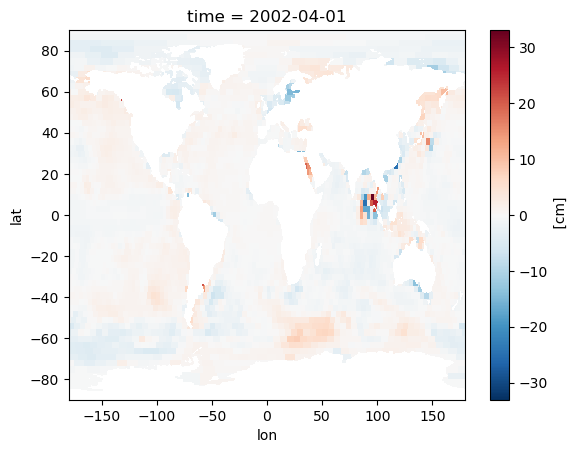

In [20]:
grace_common.isel(time=0).plot()

In [21]:
viking_common

<xarray.DataArray 'obp_rm_dt' (time: 261, lat: 33, lon: 39)>
dask.array<getitem, shape=(261, 33, 39), dtype=float32, chunksize=(1, 1, 39), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 -33.0 -30.0 -27.0 -24.0 -21.0 ... 54.0 57.0 60.0 63.0
  * lon      (lon) float64 -96.0 -93.0 -90.0 -87.0 -84.0 ... 9.0 12.0 15.0 18.0
  * time     (time) datetime64[ns] 2002-04-01 2002-05-01 ... 2023-12-01
Attributes:
    detrended:  per-pixel polynomial (deg=1) along time
    long_name:  OBP mean-removed & detrended
    units:      cm

In [22]:
print(f"Common time period: {common_time[0]} to {common_time[-1]}")


Common time period: 2002-04-01T00:00:00.000000000 to 2023-12-01T00:00:00.000000000


In [23]:
with ProgressBar():
    grace_3deg = bin_average_ll_true2d(
            grace_common,
            res=3,
            lat_name="lat", lon_name="lon",
            # KEY CHANGE: small time chunks; single spatial chunks
            #prechunk={"time": -1, "lat": -1, "lon": -1},
            # Optional: reshape the OUTPUT into nicer worker-sized tiles
            #postchunk={"time": 12, "lat": 256, "lon": 256},
            #persist_cut=True,   # if your function supports this, it helps
        ).persist()

[########################################] | 100% Completed | 3.56 ss


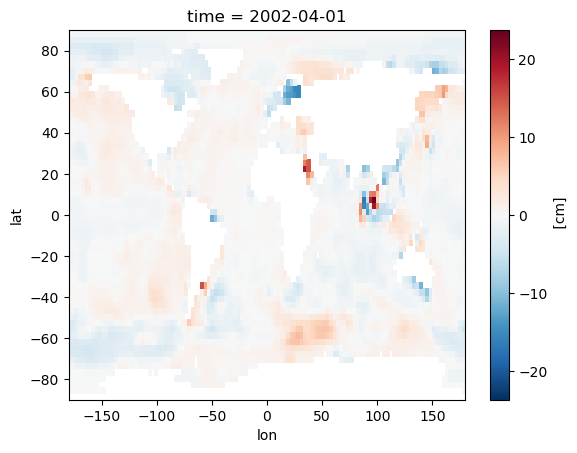

In [24]:
grace_3deg.isel(time=0).plot()

In [25]:
data_lr = grace_3deg.isel(time=0)  # (lat, lon) from bin_average_ll_true2d

lat_c = data_lr["lat"].values   # centers, e.g. [..., -7.5, -4.5, -1.5, ...]
lon_c = data_lr["lon"].values   # centers, e.g. [..., -46.5, -43.5, -40.5, ...]

dlat = float(lat_c[1] - lat_c[0])   # should be ~3.0
dlon = float(lon_c[1] - lon_c[0])   # should be ~3.0

import numpy as np

# latitude edges (length Nlat+1)
lat_edges = np.empty(lat_c.size + 1, dtype=float)
lat_edges[1:-1] = 0.5 * (lat_c[:-1] + lat_c[1:])
lat_edges[0]    = lat_c[0]  - 0.5 * dlat
lat_edges[-1]   = lat_c[-1] + 0.5 * dlat

# longitude edges (length Nlon+1)
lon_edges = np.empty(lon_c.size + 1, dtype=float)
lon_edges[1:-1] = 0.5 * (lon_c[:-1] + lon_c[1:])
lon_edges[0]    = lon_c[0]  - 0.5 * dlon
lon_edges[-1]   = lon_c[-1] + 0.5 * dlon



In [26]:
import xarray as xr
import numpy as np

# 1. Remove last element from edge arrays
lat_edges_trim = lat_edges[:-1]   # length 34
lon_edges_trim = lon_edges[:-1]   # length 40

# (Optional sanity check)
print(len(lat_edges_trim), grace_3deg.sizes["lat"])  # should both be 34
print(len(lon_edges_trim), grace_3deg.sizes["lon"])  # should both be 40

# 2. Replace lat/lon coordinates in obp_3deg with trimmed edge arrays
grace_3deg_regridded = grace_3deg.assign_coords(
    lat=("lat", lat_edges_trim),
    lon=("lon", lon_edges_trim),
)

# Now obp_3deg_regridded has lat/lon coords equal to the (trimmed) edge arrays
#print(obp_3deg_regridded)

60 60
120 120


In [27]:
grace_3deg_regridded

<xarray.DataArray (time: 261, lat: 60, lon: 120)>
dask.array<reshape, shape=(261, 60, 120), dtype=float64, chunksize=(261, 1, 120), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 -90.0 -87.0 -84.0 -81.0 -78.0 ... 78.0 81.0 84.0 87.0
  * lon      (lon) float64 -180.0 -177.0 -174.0 -171.0 ... 171.0 174.0 177.0
  * time     (time) datetime64[ns] 2002-04-01 2002-05-01 ... 2023-12-01
Attributes:
    units:      cm
    detrended:  per-pixel polynomial (deg=1) along time

In [28]:
grace_3deg_regridded = grace_3deg_regridded.sel(lat=slice(-33, 63), lon=slice(-96, 18))
grace_3deg_regridded

<xarray.DataArray (time: 261, lat: 33, lon: 39)>
dask.array<getitem, shape=(261, 33, 39), dtype=float64, chunksize=(261, 1, 39), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 -33.0 -30.0 -27.0 -24.0 -21.0 ... 54.0 57.0 60.0 63.0
  * lon      (lon) float64 -96.0 -93.0 -90.0 -87.0 -84.0 ... 9.0 12.0 15.0 18.0
  * time     (time) datetime64[ns] 2002-04-01 2002-05-01 ... 2023-12-01
Attributes:
    units:      cm
    detrended:  per-pixel polynomial (deg=1) along time

In [29]:
Raw_cor = xr.corr(grace_3deg_regridded, viking_common, dim="time").compute()
VIKING_bp_std = viking_common.std(dim = "time").compute()
GRACE_bp_std = grace_3deg_regridded.std(dim = "time").compute()

In [30]:
GRACE_bp_std

<xarray.DataArray (lat: 33, lon: 39)>
array([[1.3702034 , 1.31739341, 1.21616972, ..., 0.75915592, 0.77864516,
        0.77804298],
       [1.30157518, 1.22498209, 1.1081051 , ..., 0.71933766, 0.84085223,
               nan],
       [1.07335867, 1.05457417, 1.00828754, ..., 0.80213608,        nan,
               nan],
       ...,
       [3.72961645, 3.74345861, 3.55867229, ...,        nan, 8.90577835,
        9.33248854],
       [3.6948601 , 3.66857126, 3.79178122, ...,        nan, 6.89451923,
        8.7884531 ],
       [       nan, 3.68913303, 3.62697645, ..., 2.32747922,        nan,
        8.3233024 ]])
Coordinates:
  * lat      (lat) float64 -33.0 -30.0 -27.0 -24.0 -21.0 ... 54.0 57.0 60.0 63.0
  * lon      (lon) float64 -96.0 -93.0 -90.0 -87.0 -84.0 ... 9.0 12.0 15.0 18.0

In [31]:
VIKING_bp_std

<xarray.DataArray 'obp_rm_dt' (lat: 33, lon: 39)>
array([[ 0.99950075,  0.983085  ,  0.966517  , ...,  0.3748474 ,
         0.6688836 ,         nan],
       [ 0.95945144,  0.9151271 ,  0.8913447 , ...,  0.26807395,
         1.2655041 ,         nan],
       [ 0.8883771 ,  0.8550062 ,  0.81809425, ...,  0.4444602 ,
                nan,         nan],
       ...,
       [ 2.3882883 ,  3.1833487 ,  2.991203  , ...,         nan,
                nan, 13.102575  ],
       [ 0.4744779 ,  0.4419619 ,  0.8527122 , ...,         nan,
                nan, 12.953715  ],
       [ 0.4744779 ,  0.4744779 ,  0.4744779 , ...,         nan,
                nan,         nan]], dtype=float32)
Coordinates:
  * lat      (lat) float64 -33.0 -30.0 -27.0 -24.0 -21.0 ... 54.0 57.0 60.0 63.0
  * lon      (lon) float64 -96.0 -93.0 -90.0 -87.0 -84.0 ... 9.0 12.0 15.0 18.0

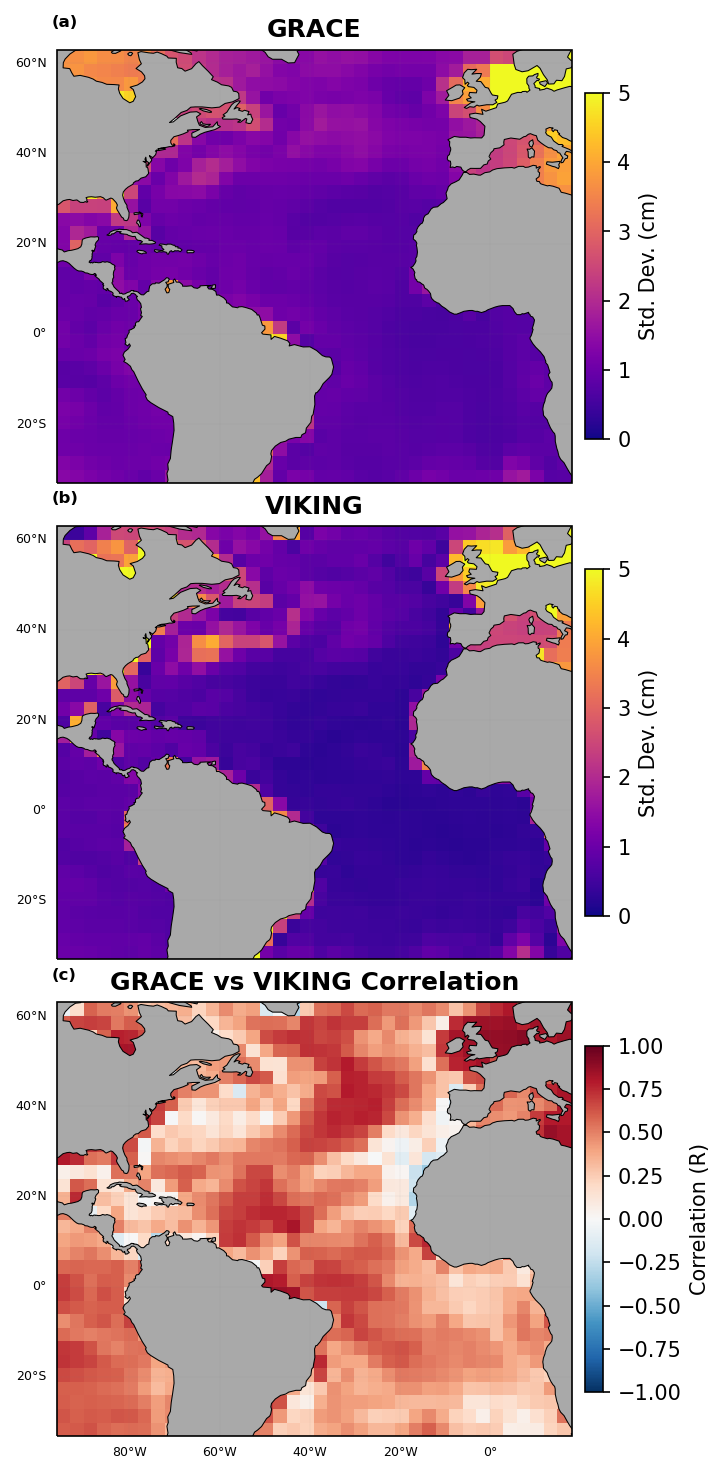

In [144]:
#%%time
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

# Define the datasets and titles
data_list = [GRACE_bp_std, VIKING_bp_std, Raw_cor]
coord_list = [GRACE_bp_std, VIKING_bp_std, Raw_cor]
title_list = [
    "GRACE",
    "VIKING",
    "GRACE vs VIKING Correlation"
]
labels = ['(a)', '(b)', '(c)']

# Create the figure and axes (3 rows, 1 column)
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(6, 12), dpi=150,
                         subplot_kw={'projection': ccrs.PlateCarree(central_longitude=0)},
                         gridspec_kw={'hspace': 0.1})  # Reduce from default ~0.2

# Loop through each subplot
for i, (ax, data, coord, title) in enumerate(zip(axes, data_list, coord_list, title_list)):
    
    # Choose color scale
    if i < 2:
        cmap = 'plasma'
        vmin, vmax = 0, 5  # assuming std dev range
    else:
        cmap = 'RdBu_r'
        vmin, vmax = -1, 1  # correlation range

    # Plot data
    pc = ax.pcolormesh(coord.lon, coord.lat, data,
                       transform=ccrs.PlateCarree(),
                       cmap=cmap, vmin=vmin, vmax=vmax)

    # Map formatting
    #ax.set_global()
    gl = ax.gridlines(draw_labels=True, linestyle='dashed', linewidth=0.05, color='gray')
    gl.right_labels = False
    gl.top_labels = False
    gl.bottom_labels = (i == 2)
    gl.xlabel_style = {'fontsize': 6}
    gl.ylabel_style = {'fontsize': 6}

    ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '110m',
                                                linewidth=0.5, edgecolor='black',
                                                facecolor='darkgray'))

    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.text(-0.01, 1.08, labels[i], transform=ax.transAxes,
            fontsize=8, fontweight='bold', va='top', ha='left',
            bbox=dict(facecolor='white', edgecolor='none', pad=1.5, alpha=0.6))

    # Add vertical colorbar to the right of each panel
    cbar = fig.colorbar(pc, ax=ax, orientation='vertical', pad=0.02, shrink=0.8)
    if i < 2:
        cbar.set_label("Std. Dev. (cm)", fontsize=10)
    else:
        cbar.set_label("Correlation (R)", fontsize=10)

# Layout adjustment
#plt.tight_layout()
#plt.savefig("GRACE_VIKING_Correlation_Std.png", dpi=300, bbox_inches='tight')
plt.show()


In [34]:
import numpy as np
import xarray as xr
from scipy.stats import t

# sample size at each grid cell
n = grace_common.sizes["time"]   # here = 261

df = n - 2

r = Raw_cor  # shorthand

# compute t-statistic
t_stat = r * np.sqrt(df / (1 - r**2))

# two-sided p-value
pval = xr.apply_ufunc(
    lambda x: 2 * (1 - t.cdf(np.abs(x), df)),
    t_stat,
    dask='parallelized',
    output_dtypes=[float]
)
alpha = 0.05
insig = pval >= alpha   # boolean mask of NOT significant

In [35]:
insig

<xarray.DataArray (lat: 33, lon: 39)>
array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [ True, False, False, ..., False, False, False],
       [False,  True,  True, ..., False, False, False]])
Coordinates:
  * lat      (lat) float64 -33.0 -30.0 -27.0 -24.0 -21.0 ... 54.0 57.0 60.0 63.0
  * lon      (lon) float64 -96.0 -93.0 -90.0 -87.0 -84.0 ... 9.0 12.0 15.0 18.0

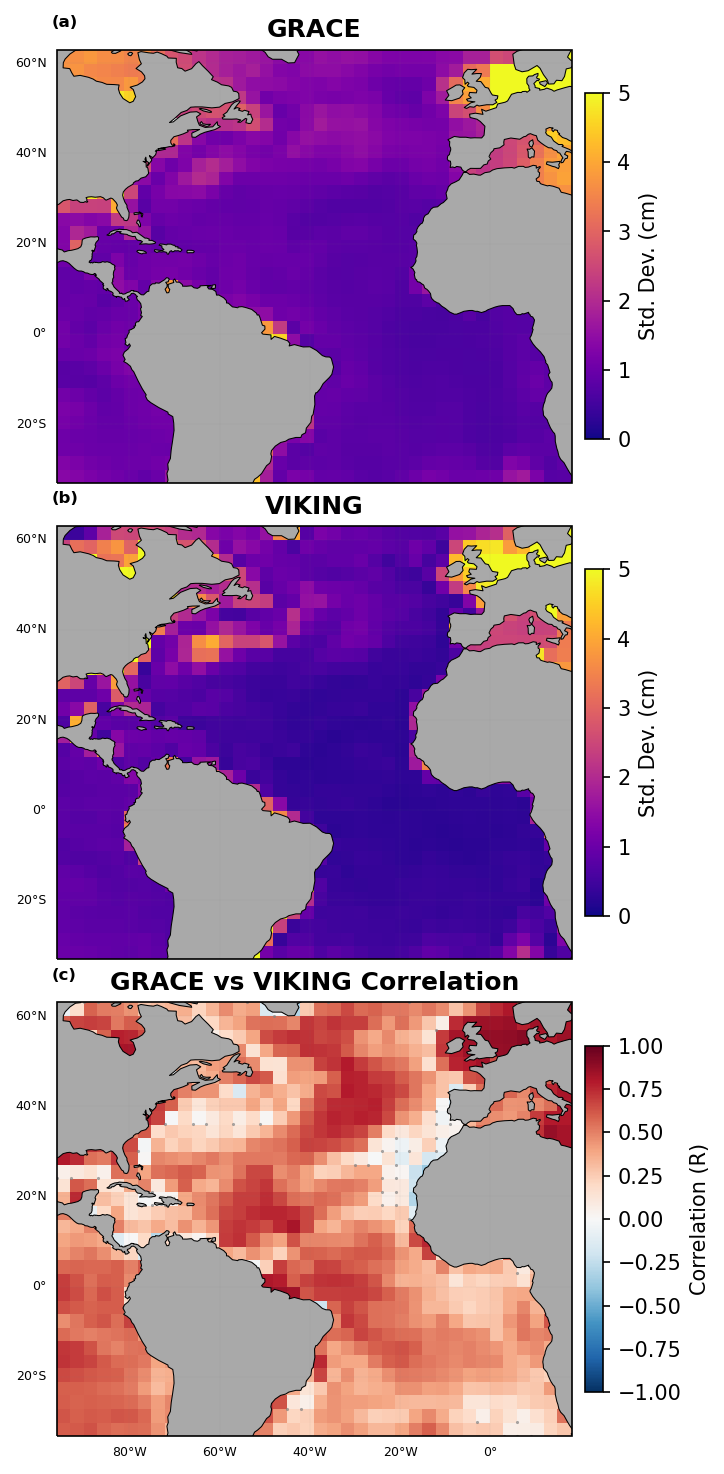

In [147]:
#%%time
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

# Define the datasets and titles
data_list = [GRACE_bp_std, VIKING_bp_std, Raw_cor]
coord_list = [GRACE_bp_std, VIKING_bp_std, Raw_cor]
title_list = [
    "GRACE",
    "VIKING",
    "GRACE vs VIKING Correlation"
]
labels = ['(a)', '(b)', '(c)']

# Create the figure and axes (3 rows, 1 column)
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(6, 12), dpi=150,
                         subplot_kw={'projection': ccrs.PlateCarree(central_longitude=0)},
                         gridspec_kw={'hspace': 0.1})  # Reduce from default ~0.2

# Loop through each subplot
for i, (ax, data, coord, title) in enumerate(zip(axes, data_list, coord_list, title_list)):
    
    # Choose color scale
    if i < 2:
        cmap = 'plasma'
        vmin, vmax = 0, 5  # assuming std dev range
    else:
        cmap = 'RdBu_r'
        vmin, vmax = -1, 1  # correlation range

    # Plot data
    pc = ax.pcolormesh(coord.lon, coord.lat, data,
                       transform=ccrs.PlateCarree(),
                       cmap=cmap, vmin=vmin, vmax=vmax)

    if i == 2:
    # Add stippling for insignificant correlations
        Y, X = np.meshgrid(coord.lat, coord.lon, indexing="ij")
        
        ax.scatter(
            X[insig],
            Y[insig],
            s=1.0,                  # marker size
            color='gray',
            marker='.',
            alpha=0.7,
            transform=ccrs.PlateCarree()
        )


    # Map formatting
    #ax.set_global()
    gl = ax.gridlines(draw_labels=True, linestyle='dashed', linewidth=0.05, color='gray')
    gl.right_labels = False
    gl.top_labels = False
    gl.bottom_labels = (i == 2)
    gl.xlabel_style = {'fontsize': 6}
    gl.ylabel_style = {'fontsize': 6}

    ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '110m',
                                                linewidth=0.5, edgecolor='black',
                                                facecolor='darkgray'))

    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.text(-0.01, 1.08, labels[i], transform=ax.transAxes,
            fontsize=8, fontweight='bold', va='top', ha='left',
            bbox=dict(facecolor='white', edgecolor='none', pad=1.5, alpha=0.6))

    # Add vertical colorbar to the right of each panel
    cbar = fig.colorbar(pc, ax=ax, orientation='vertical', pad=0.02, shrink=0.8)
    if i < 2:
        cbar.set_label("Std. Dev. (cm)", fontsize=10)
    else:
        cbar.set_label("Correlation (R)", fontsize=10)

# Layout adjustment
#plt.tight_layout()
#plt.savefig("GRACE_VIKING_Correlation_Std.png", dpi=300, bbox_inches='tight')
plt.show()


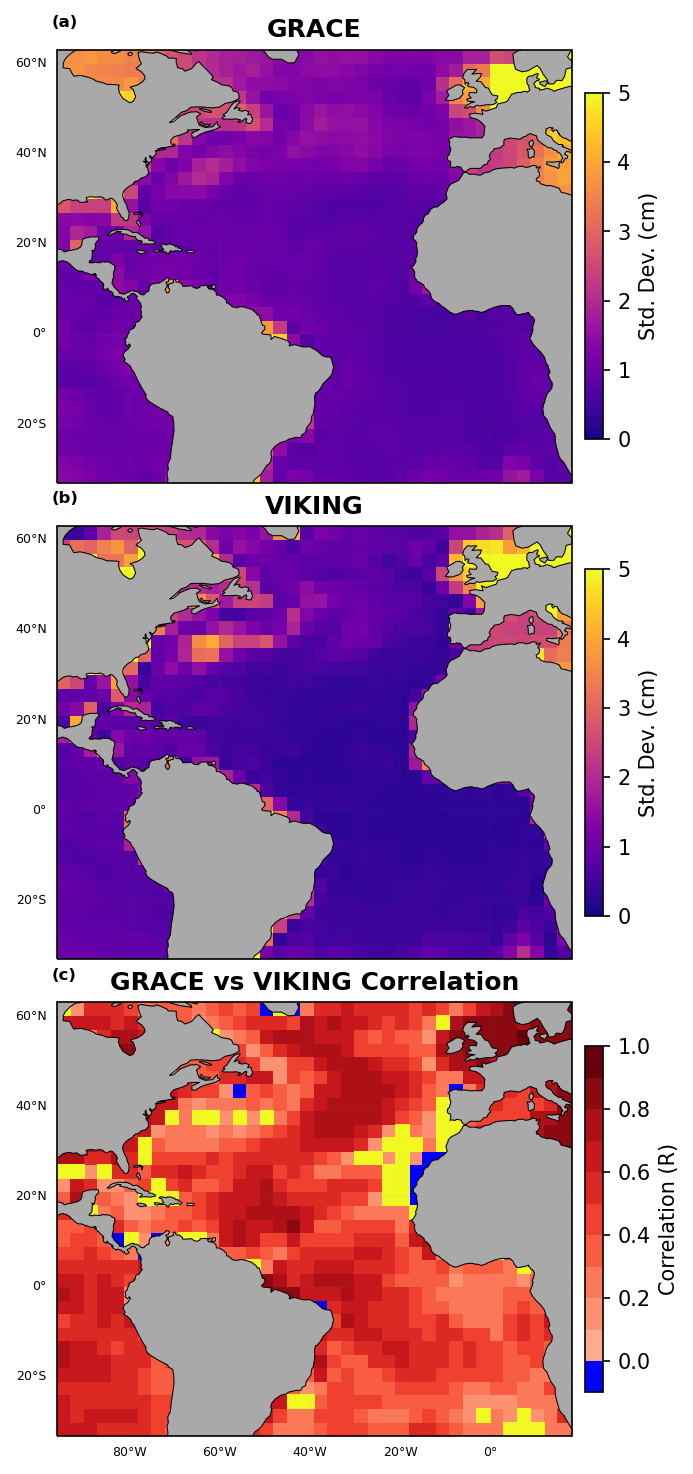

In [148]:
import matplotlib.colors as mcolors

# Define the datasets and titles
data_list = [GRACE_bp_std, VIKING_bp_std, Raw_cor]
coord_list = [GRACE_bp_std, VIKING_bp_std, Raw_cor]
title_list = [
    "GRACE",
    "VIKING",
    "GRACE vs VIKING Correlation"
]
labels = ['(a)', '(b)', '(c)']

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(6, 12), dpi=150,
                         subplot_kw={'projection': ccrs.PlateCarree(central_longitude=0)},
                         gridspec_kw={'hspace': 0.1})  # Reduce from default ~0.2

# Loop through each subplot
for i, (ax, data, coord, title) in enumerate(zip(axes, data_list, coord_list, title_list)):
    
    # Choose color scale
    if i < 2:
        cmap = 'plasma'
        vmin, vmax = 0, 5  # assuming std dev range
        norm = None
    else:
        # Discrete cmap for correlation:
        #   - blue for all negative values
        #   - Reds in discrete bins for 0–1
        boundaries = [-1.0, 0.0, 0.1, 0.2, 0.3, 0.4, 
                      0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
        # first color: blue for [-1,0)
        # remaining colors: discrete Reds bins for [0,1]
        red_colors = [plt.cm.Reds(x) for x in np.linspace(0.3, 1.0, len(boundaries) - 2)]
        colors = ['blue'] + red_colors
        cmap = mcolors.ListedColormap(colors)
        norm = mcolors.BoundaryNorm(boundaries, cmap.N)
        vmin, vmax = -1, 1  # keep full correlation range

    # --- main field (std or correlation) ---
    pc = ax.pcolormesh(
        coord.lon, coord.lat, data,
        transform=ccrs.PlateCarree(),
        cmap=cmap, vmin=vmin, vmax=vmax,
        norm=norm
    )

    # --- overlay for insignificant correlations, as colored pixels ---
    if i == 2:
        # insig is a boolean (lat, lon): True where p >= alpha
        # build a mask with 1 where insignificant, NaN elsewhere
        insig_mask = np.where(insig, 1.0, np.nan)

        ax.pcolormesh(
            coord.lon, coord.lat, insig_mask,
            transform=ccrs.PlateCarree(),
            cmap='plasma',       # unchanged
            vmin=0, vmax=1,        # full range for mask
            alpha=1,             # transparency so underlying field still visible
        )

    # Map formatting
    gl = ax.gridlines(draw_labels=True, linestyle='dashed',
                      linewidth=0.05, color='gray')
    gl.right_labels = False
    gl.top_labels = False
    gl.bottom_labels = (i == 2)
    gl.xlabel_style = {'fontsize': 6}
    gl.ylabel_style = {'fontsize': 6}

    ax.add_feature(cfeature.NaturalEarthFeature(
        'physical', 'land', '110m',
        linewidth=0.5, edgecolor='black',
        facecolor='darkgray'
    ))

    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.text(
        -0.01, 1.08, labels[i], transform=ax.transAxes,
        fontsize=8, fontweight='bold', va='top', ha='left',
        bbox=dict(facecolor='white', edgecolor='none', pad=1.5, alpha=0.6)
    )

    cbar = fig.colorbar(pc, ax=ax, orientation='vertical', pad=0.02, shrink=0.8)
    if i < 2:
        cbar.set_label("Std. Dev. (cm)", fontsize=10)
    else:
        cbar.set_label("Correlation (R)", fontsize=10)
plt.savefig("GRACE_VIKING_Correlation_Std_25_filter.png", dpi=300, bbox_inches='tight')
plt.show()


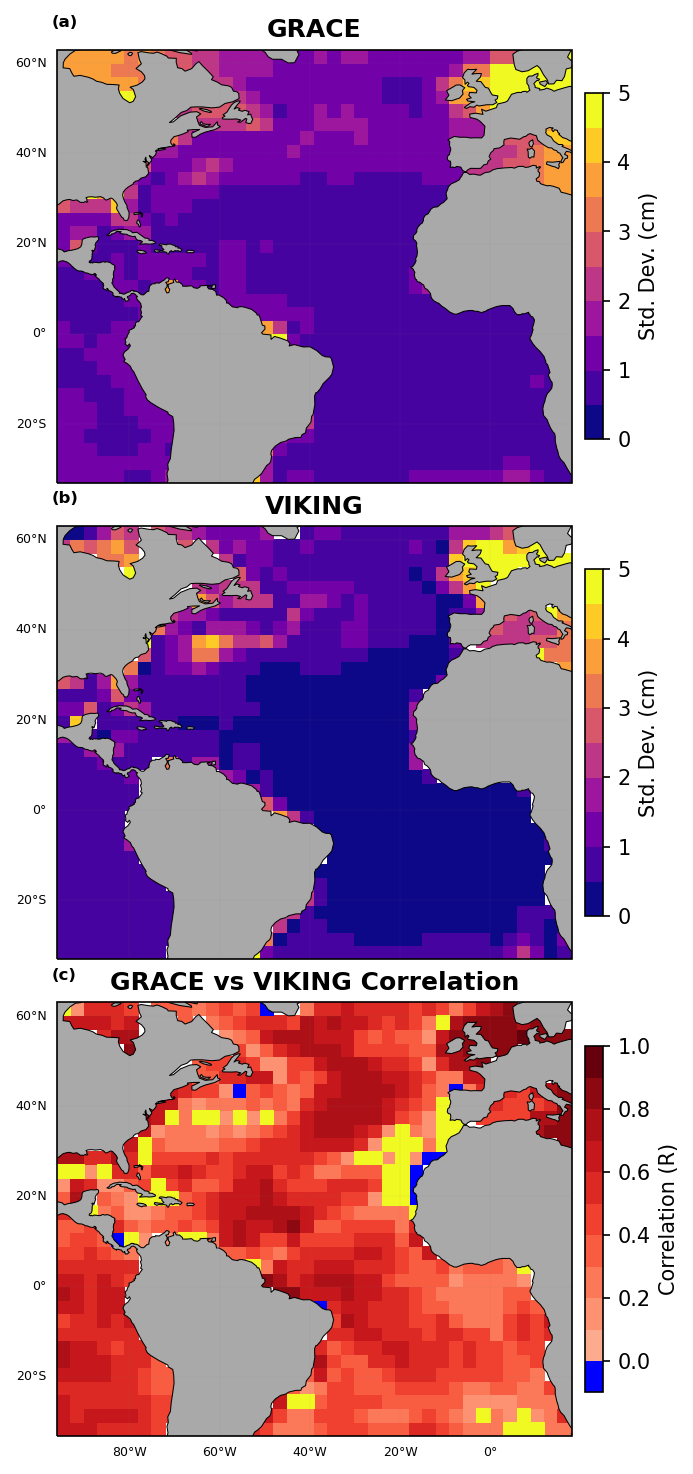

In [38]:
import matplotlib.colors as mcolors

# Define the datasets and titles
data_list = [GRACE_bp_std, VIKING_bp_std, Raw_cor]
coord_list = [GRACE_bp_std, VIKING_bp_std, Raw_cor]
title_list = [
    "GRACE",
    "VIKING",
    "GRACE vs VIKING Correlation"
]
labels = ['(a)', '(b)', '(c)']

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(6, 12), dpi=150,
                         subplot_kw={'projection': ccrs.PlateCarree(central_longitude=0)},
                         gridspec_kw={'hspace': 0.1})  # Reduce from default ~0.2

# Loop through each subplot
for i, (ax, data, coord, title) in enumerate(zip(axes, data_list, coord_list, title_list)):
    
    # Choose color scale
    if i < 2:
        # discrete plasma in 1-unit intervals from 0 to 5
        vmin, vmax = 0, 5  # assuming std dev range
        boundaries = np.arange(vmin, vmax + 0.5, 0.5)  # [0,1,2,3,4,5]
        # one color per interval
        colors = [plt.cm.plasma(x) for x in np.linspace(0, 1, len(boundaries) - 1)]
        cmap = mcolors.ListedColormap(colors)
        norm = mcolors.BoundaryNorm(boundaries, cmap.N)
    else:
        # Discrete cmap for correlation:
        #   - blue for all negative values
        #   - Reds in discrete bins for 0–1
        boundaries = [-1.0, 0.0, 0.1, 0.2, 0.3, 0.4, 
                      0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
        # first color: blue for [-1,0)
        # remaining colors: discrete Reds bins for [0,1]
        red_colors = [plt.cm.Reds(x) for x in np.linspace(0.3, 1.0, len(boundaries) - 2)]
        colors = ['blue'] + red_colors
        cmap = mcolors.ListedColormap(colors)
        norm = mcolors.BoundaryNorm(boundaries, cmap.N)
        vmin, vmax = -1, 1  # keep full correlation range

    # --- main field (std or correlation) ---
    pc = ax.pcolormesh(
        coord.lon, coord.lat, data,
        transform=ccrs.PlateCarree(),
        cmap=cmap, vmin=vmin, vmax=vmax,
        norm=norm
    )

    # --- overlay for insignificant correlations, as colored pixels ---
    if i == 2:
        # insig is a boolean (lat, lon): True where p >= alpha
        # build a mask with 1 where insignificant, NaN elsewhere
        insig_mask = np.where(insig, 1.0, np.nan)

        ax.pcolormesh(
            coord.lon, coord.lat, insig_mask,
            transform=ccrs.PlateCarree(),
            cmap='plasma',       # unchanged
            vmin=0, vmax=1,        # full range for mask
            alpha=1,             # transparency so underlying field still visible
        )

    # Map formatting
    gl = ax.gridlines(draw_labels=True, linestyle='dashed',
                      linewidth=0.05, color='gray')
    gl.right_labels = False
    gl.top_labels = False
    gl.bottom_labels = (i == 2)
    gl.xlabel_style = {'fontsize': 6}
    gl.ylabel_style = {'fontsize': 6}

    ax.add_feature(cfeature.NaturalEarthFeature(
        'physical', 'land', '110m',
        linewidth=0.5, edgecolor='black',
        facecolor='darkgray'
    ))

    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.text(
        -0.01, 1.08, labels[i], transform=ax.transAxes,
        fontsize=8, fontweight='bold', va='top', ha='left',
        bbox=dict(facecolor='white', edgecolor='none', pad=1.5, alpha=0.6)
    )

    cbar = fig.colorbar(pc, ax=ax, orientation='vertical', pad=0.02, shrink=0.8)
    if i < 2:
        cbar.set_label("Std. Dev. (cm)", fontsize=10)
    else:
        cbar.set_label("Correlation (R)", fontsize=10)

plt.savefig("GRACE_VIKING_Correlation_Std_25_filter.png", dpi=300, bbox_inches='tight')
plt.show()


In [51]:
grace_on_viking = grace_common.interp(
    lat=viking_common['lat'],
    lon=viking_common['lon'],
    method="nearest",
)


viking_on_grace = viking_common.interp(
    lat=grace_common['lat'],
    lon=grace_common['lon'],
    method="nearest",
)

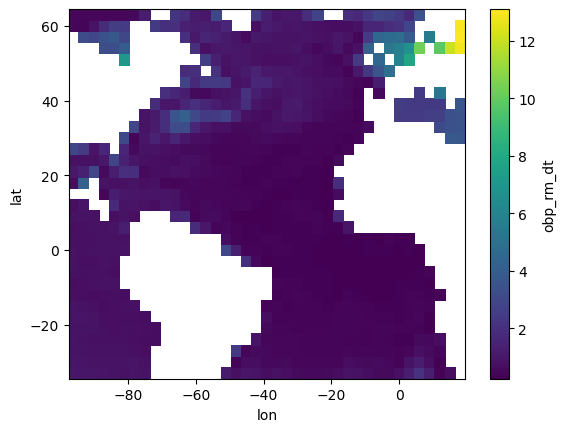

In [52]:
viking_common.std(dim='time').plot()

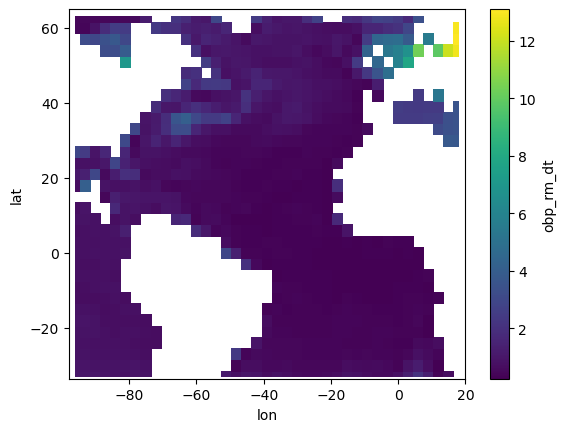

In [53]:
viking_on_grace.std(dim='time').plot()

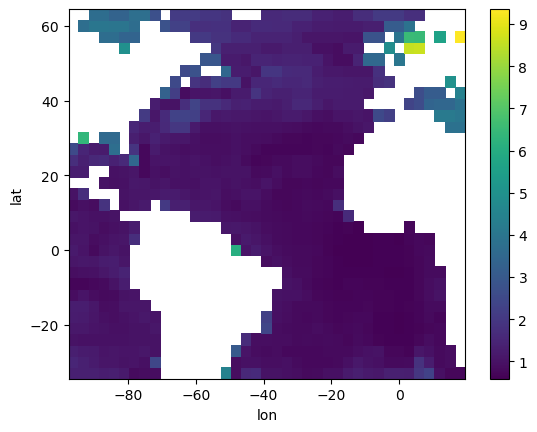

In [54]:
grace_on_viking.std(dim='time').plot()

In [55]:
Raw_cor = xr.corr(grace_on_viking, viking_common, dim="time").compute()
VIKING_bp_std = viking_common.std(dim = "time").compute()
GRACE_bp_std = grace_on_viking.std(dim = "time").compute()

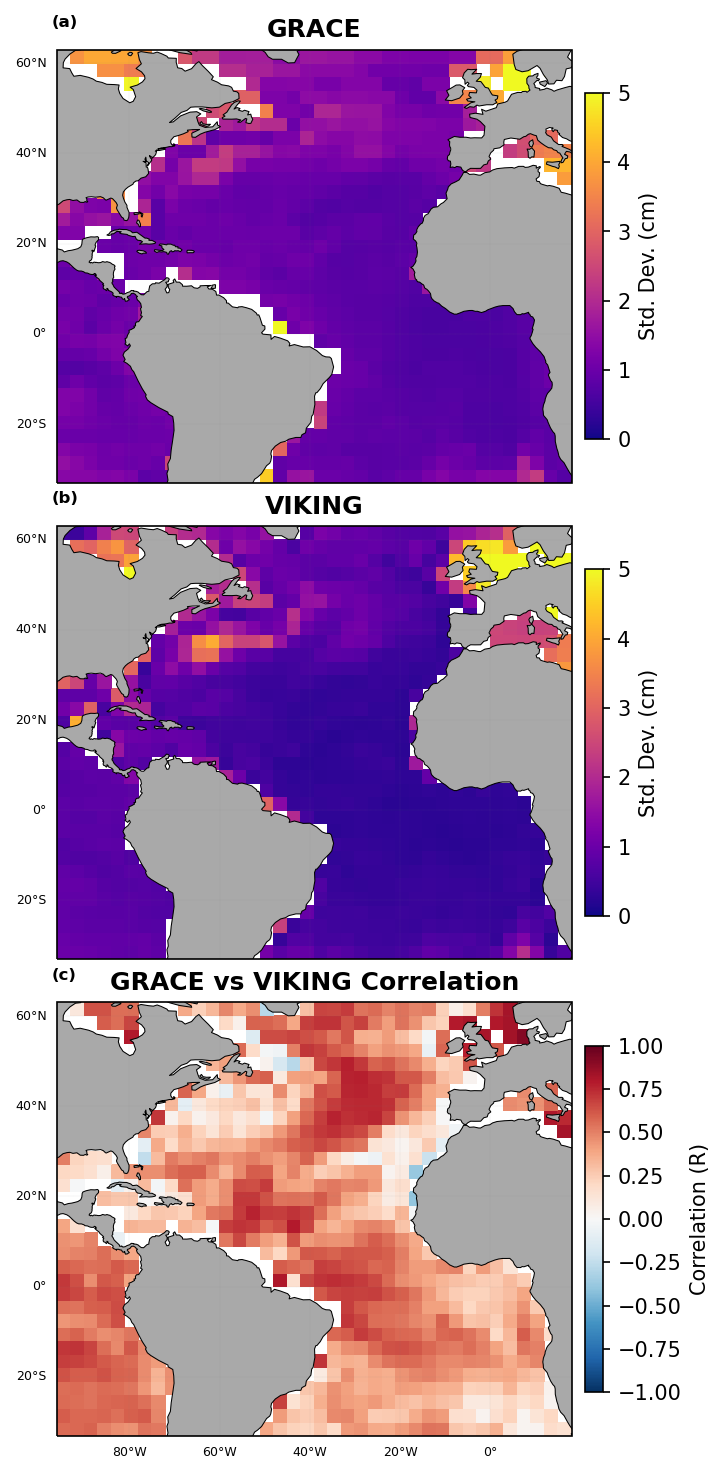

In [32]:
#%%time
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

# Define the datasets and titles
data_list = [GRACE_bp_std, VIKING_bp_std, Raw_cor]
coord_list = [GRACE_bp_std, VIKING_bp_std, Raw_cor]
title_list = [
    "GRACE",
    "VIKING",
    "GRACE vs VIKING Correlation"
]
labels = ['(a)', '(b)', '(c)']

# Create the figure and axes (3 rows, 1 column)
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(6, 12), dpi=150,
                         subplot_kw={'projection': ccrs.PlateCarree(central_longitude=0)},
                         gridspec_kw={'hspace': 0.1})  # Reduce from default ~0.2

# Loop through each subplot
for i, (ax, data, coord, title) in enumerate(zip(axes, data_list, coord_list, title_list)):
    
    # Choose color scale
    if i < 2:
        cmap = 'plasma'
        vmin, vmax = 0, 5  # assuming std dev range
    else:
        cmap = 'RdBu_r'
        vmin, vmax = -1, 1  # correlation range

    # Plot data
    pc = ax.pcolormesh(coord.lon, coord.lat, data,
                       transform=ccrs.PlateCarree(),
                       cmap=cmap, vmin=vmin, vmax=vmax)

    # Map formatting
    #ax.set_global()
    gl = ax.gridlines(draw_labels=True, linestyle='dashed', linewidth=0.05, color='gray')
    gl.right_labels = False
    gl.top_labels = False
    gl.bottom_labels = (i == 2)
    gl.xlabel_style = {'fontsize': 6}
    gl.ylabel_style = {'fontsize': 6}

    ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '110m',
                                                linewidth=0.5, edgecolor='black',
                                                facecolor='darkgray'))

    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.text(-0.01, 1.08, labels[i], transform=ax.transAxes,
            fontsize=8, fontweight='bold', va='top', ha='left',
            bbox=dict(facecolor='white', edgecolor='none', pad=1.5, alpha=0.6))

    # Add vertical colorbar to the right of each panel
    cbar = fig.colorbar(pc, ax=ax, orientation='vertical', pad=0.02, shrink=0.8)
    if i < 2:
        cbar.set_label("Std. Dev. (cm)", fontsize=10)
    else:
        cbar.set_label("Correlation (R)", fontsize=10)

# Layout adjustment
#plt.tight_layout()
#plt.savefig("GRACE_VIKING_Correlation_Std.png", dpi=300, bbox_inches='tight')
plt.show()


In [33]:
import numpy as np
import xarray as xr
from scipy.stats import t

# sample size at each grid cell
n = grace_common.sizes["time"]   # here = 261

df = n - 2

r = Raw_cor  # shorthand

# compute t-statistic
t_stat = r * np.sqrt(df / (1 - r**2))

# two-sided p-value
pval = xr.apply_ufunc(
    lambda x: 2 * (1 - t.cdf(np.abs(x), df)),
    t_stat,
    dask='parallelized',
    output_dtypes=[float]
)
alpha = 0.05
insig = pval >= alpha   # boolean mask of NOT significant

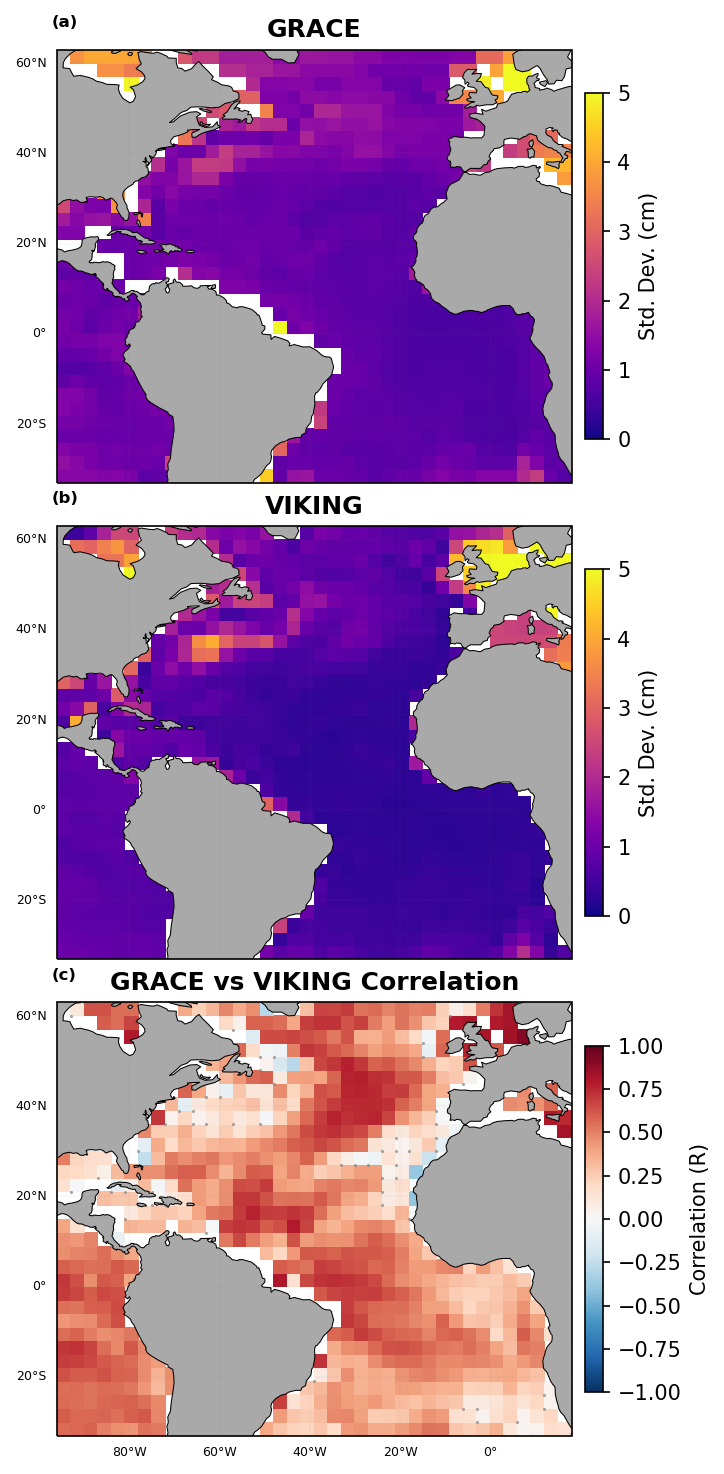

In [34]:
#%%time
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

# Define the datasets and titles
data_list = [GRACE_bp_std, VIKING_bp_std, Raw_cor]
coord_list = [GRACE_bp_std, VIKING_bp_std, Raw_cor]
title_list = [
    "GRACE",
    "VIKING",
    "GRACE vs VIKING Correlation"
]
labels = ['(a)', '(b)', '(c)']

# Create the figure and axes (3 rows, 1 column)
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(6, 12), dpi=150,
                         subplot_kw={'projection': ccrs.PlateCarree(central_longitude=0)},
                         gridspec_kw={'hspace': 0.1})  # Reduce from default ~0.2

# Loop through each subplot
for i, (ax, data, coord, title) in enumerate(zip(axes, data_list, coord_list, title_list)):
    
    # Choose color scale
    if i < 2:
        cmap = 'plasma'
        vmin, vmax = 0, 5  # assuming std dev range
    else:
        cmap = 'RdBu_r'
        vmin, vmax = -1, 1  # correlation range

    # Plot data
    pc = ax.pcolormesh(coord.lon, coord.lat, data,
                       transform=ccrs.PlateCarree(),
                       cmap=cmap, vmin=vmin, vmax=vmax)

    if i == 2:
    # Add stippling for insignificant correlations
        Y, X = np.meshgrid(coord.lat, coord.lon, indexing="ij")
        
        ax.scatter(
            X[insig],
            Y[insig],
            s=1.0,                  # marker size
            color='gray',
            marker='.',
            alpha=0.7,
            transform=ccrs.PlateCarree()
        )


    # Map formatting
    #ax.set_global()
    gl = ax.gridlines(draw_labels=True, linestyle='dashed', linewidth=0.05, color='gray')
    gl.right_labels = False
    gl.top_labels = False
    gl.bottom_labels = (i == 2)
    gl.xlabel_style = {'fontsize': 6}
    gl.ylabel_style = {'fontsize': 6}

    ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '110m',
                                                linewidth=0.5, edgecolor='black',
                                                facecolor='darkgray'))

    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.text(-0.01, 1.08, labels[i], transform=ax.transAxes,
            fontsize=8, fontweight='bold', va='top', ha='left',
            bbox=dict(facecolor='white', edgecolor='none', pad=1.5, alpha=0.6))

    # Add vertical colorbar to the right of each panel
    cbar = fig.colorbar(pc, ax=ax, orientation='vertical', pad=0.02, shrink=0.8)
    if i < 2:
        cbar.set_label("Std. Dev. (cm)", fontsize=10)
    else:
        cbar.set_label("Correlation (R)", fontsize=10)

# Layout adjustment
#plt.tight_layout()
#plt.savefig("GRACE_VIKING_Correlation_Std.png", dpi=300, bbox_inches='tight')
plt.show()


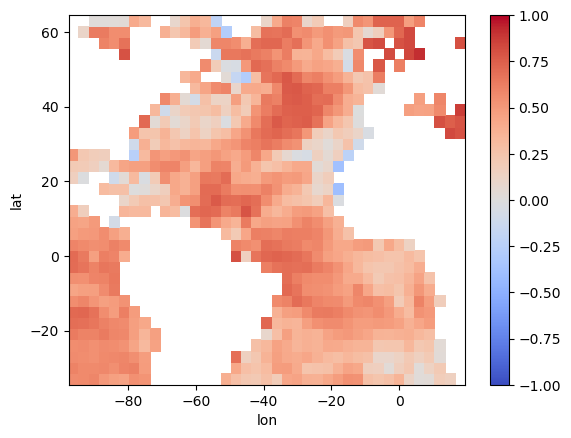

In [35]:
Raw_cor.plot(vmin = -1, vmax =1, cmap = "coolwarm")

In [36]:
print(grace_common, viking_on_grace)

<xarray.DataArray (time: 261, lat: 197, lon: 236)>
array([[[2.22768213, 2.22768213, 1.92150615, ...,        nan,
                nan,        nan],
        [2.22768213, 2.22768213, 1.92150615, ...,        nan,
                nan,        nan],
        [2.22768213, 2.22768213, 1.92150615, ...,        nan,
                nan,        nan],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
...
        [       nan,        nan,        nan, ...,        nan,
    

In [57]:
Raw_cor = xr.corr(grace_common, viking_on_grace, dim="time").compute()
VIKING_bp_std = viking_common.std(dim = "time").compute()
GRACE_bp_std = grace_common.std(dim = "time").compute()

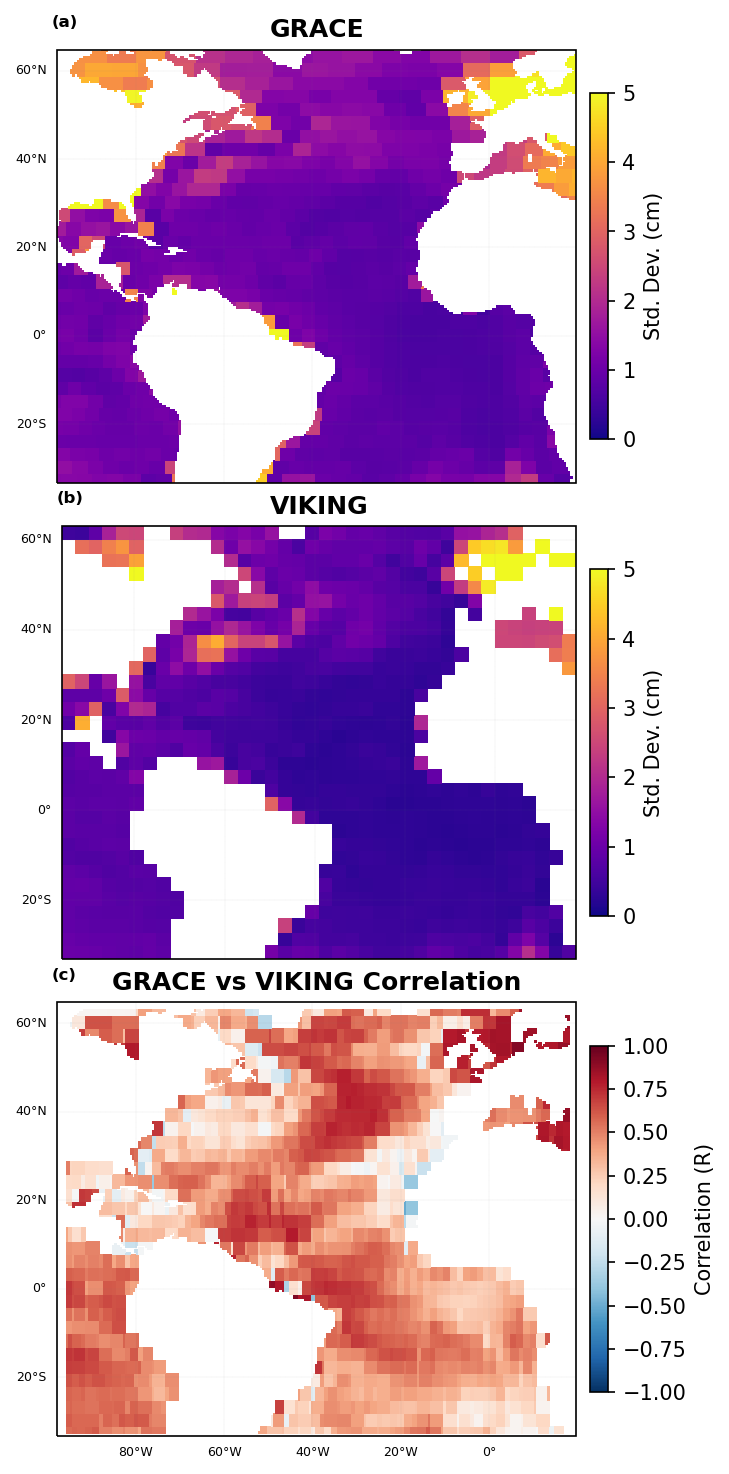

In [38]:
#%%time
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

# Define the datasets and titles
data_list = [GRACE_bp_std, VIKING_bp_std, Raw_cor]
coord_list = [GRACE_bp_std, VIKING_bp_std, Raw_cor]
title_list = [
    "GRACE",
    "VIKING",
    "GRACE vs VIKING Correlation"
]
labels = ['(a)', '(b)', '(c)']

# Create the figure and axes (3 rows, 1 column)
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(6, 12), dpi=150,
                         subplot_kw={'projection': ccrs.PlateCarree(central_longitude=0)},
                         gridspec_kw={'hspace': 0.1})  # Reduce from default ~0.2

# Loop through each subplot
for i, (ax, data, coord, title) in enumerate(zip(axes, data_list, coord_list, title_list)):
    
    # Choose color scale
    if i < 2:
        cmap = 'plasma'
        vmin, vmax = 0, 5  # assuming std dev range
    else:
        cmap = 'RdBu_r'
        vmin, vmax = -1, 1  # correlation range

    # Plot data
    pc = ax.pcolormesh(coord.lon, coord.lat, data,
                       transform=ccrs.PlateCarree(),
                       cmap=cmap, vmin=vmin, vmax=vmax)

    # Map formatting
    #ax.set_global()
    gl = ax.gridlines(draw_labels=True, linestyle='dashed', linewidth=0.05, color='gray')
    gl.right_labels = False
    gl.top_labels = False
    gl.bottom_labels = (i == 2)
    gl.xlabel_style = {'fontsize': 6}
    gl.ylabel_style = {'fontsize': 6}

    #ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '110m',
    #                                            linewidth=0.5, edgecolor='black',
    #                                            facecolor='darkgray'))

    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.text(-0.01, 1.08, labels[i], transform=ax.transAxes,
            fontsize=8, fontweight='bold', va='top', ha='left',
            bbox=dict(facecolor='white', edgecolor='none', pad=1.5, alpha=0.6))

    # Add vertical colorbar to the right of each panel
    cbar = fig.colorbar(pc, ax=ax, orientation='vertical', pad=0.02, shrink=0.8)
    if i < 2:
        cbar.set_label("Std. Dev. (cm)", fontsize=10)
    else:
        cbar.set_label("Correlation (R)", fontsize=10)

# Layout adjustment
#plt.tight_layout()
#plt.savefig("GRACE_VIKING_Correlation_Std.png", dpi=300, bbox_inches='tight')
plt.show()


In [58]:
import numpy as np
import xarray as xr
from scipy.stats import t

# sample size at each grid cell
n = grace_common.sizes["time"]   # here = 261

df = n - 2

r = Raw_cor  # shorthand

# compute t-statistic
t_stat = r * np.sqrt(df / (1 - r**2))

# two-sided p-value
pval = xr.apply_ufunc(
    lambda x: 2 * (1 - t.cdf(np.abs(x), df)),
    t_stat,
    dask='parallelized',
    output_dtypes=[float]
)
alpha = 0.05
insig = pval >= alpha   # boolean mask of NOT significant

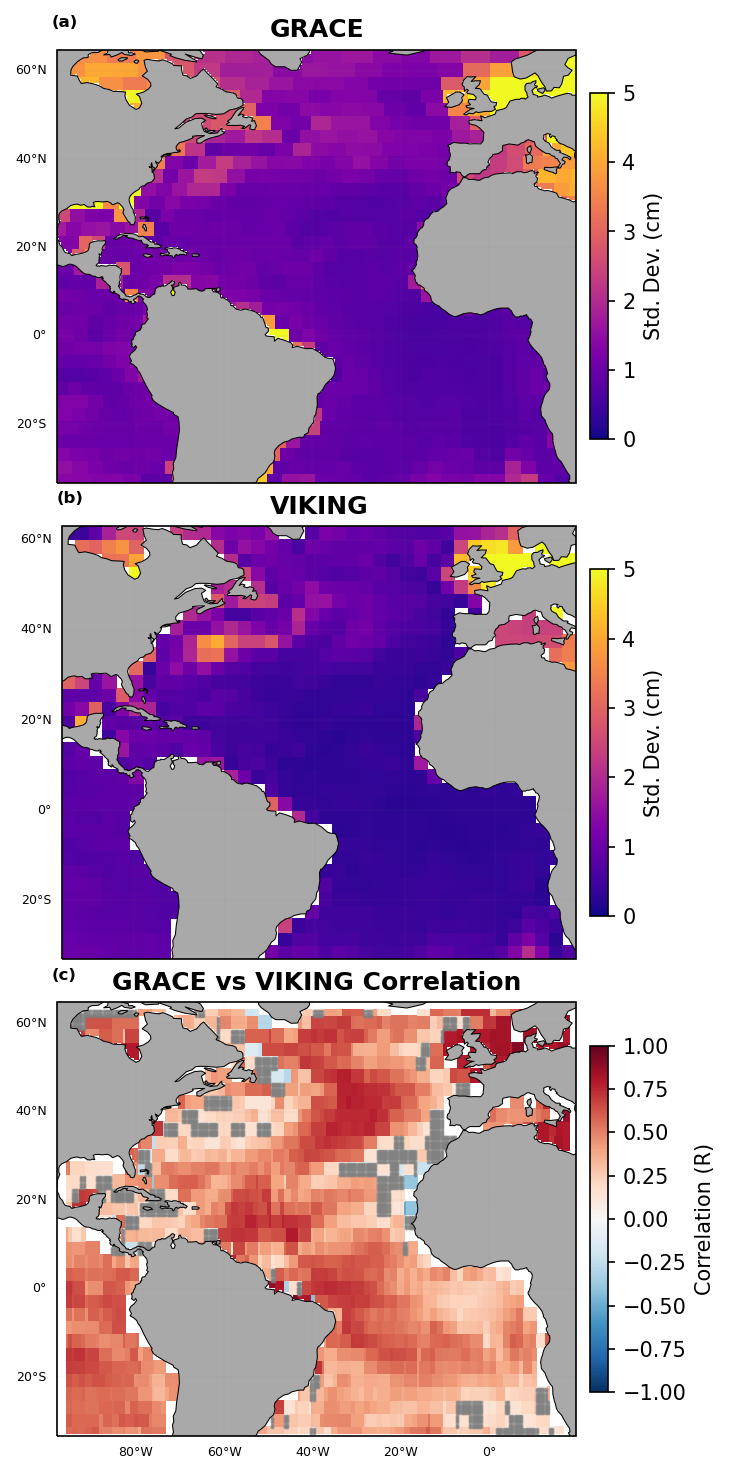

In [59]:
#%%time
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

# Define the datasets and titles
data_list = [GRACE_bp_std, VIKING_bp_std, Raw_cor]
coord_list = [GRACE_bp_std, VIKING_bp_std, Raw_cor]
title_list = [
    "GRACE",
    "VIKING",
    "GRACE vs VIKING Correlation"
]
labels = ['(a)', '(b)', '(c)']

# Create the figure and axes (3 rows, 1 column)
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(6, 12), dpi=150,
                         subplot_kw={'projection': ccrs.PlateCarree(central_longitude=0)},
                         gridspec_kw={'hspace': 0.1})  # Reduce from default ~0.2

# Loop through each subplot
for i, (ax, data, coord, title) in enumerate(zip(axes, data_list, coord_list, title_list)):
    
    # Choose color scale
    if i < 2:
        cmap = 'plasma'
        vmin, vmax = 0, 5  # assuming std dev range
    else:
        cmap = 'RdBu_r'
        vmin, vmax = -1, 1  # correlation range

    # Plot data
    pc = ax.pcolormesh(coord.lon, coord.lat, data,
                       transform=ccrs.PlateCarree(),
                       cmap=cmap, vmin=vmin, vmax=vmax)

    if i == 2:
    # Add stippling for insignificant correlations
        Y, X = np.meshgrid(coord.lat, coord.lon, indexing="ij")
        
        ax.scatter(
            X[insig],
            Y[insig],
            s=3,                  # marker size
            color='gray',
            marker='.',
            alpha=0.7,
            transform=ccrs.PlateCarree()
        )


    # Map formatting
    #ax.set_global()
    gl = ax.gridlines(draw_labels=True, linestyle='dashed', linewidth=0.05, color='gray')
    gl.right_labels = False
    gl.top_labels = False
    gl.bottom_labels = (i == 2)
    gl.xlabel_style = {'fontsize': 6}
    gl.ylabel_style = {'fontsize': 6}

    ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '110m',
                                                linewidth=0.5, edgecolor='black',
                                                facecolor='darkgray'))

    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.text(-0.01, 1.08, labels[i], transform=ax.transAxes,
            fontsize=8, fontweight='bold', va='top', ha='left',
            bbox=dict(facecolor='white', edgecolor='none', pad=1.5, alpha=0.6))

    # Add vertical colorbar to the right of each panel
    cbar = fig.colorbar(pc, ax=ax, orientation='vertical', pad=0.02, shrink=0.8)
    if i < 2:
        cbar.set_label("Std. Dev. (cm)", fontsize=10)
    else:
        cbar.set_label("Correlation (R)", fontsize=10)

# Layout adjustment
#plt.tight_layout()
plt.savefig("GRACE_VIKING_Correlation_Std2_bin_filter.png", dpi=300, bbox_inches='tight')
plt.show()


In [79]:
viking_bp_half_deg = xr.open_dataset('/glade/work/netige/Data/GRACE/viking_bp_half_deg.nc')

In [80]:
viking_bp_half_deg = viking_bp_half_deg.viking_bp_half_deg

In [81]:
viking_bp_half_deg

<xarray.DataArray 'viking_bp_half_deg' (time: 261, lat: 197, lon: 236)>
[12134412 values with dtype=float64]
Coordinates:
  * time     (time) datetime64[ns] 2002-04-01 2002-05-01 ... 2023-12-01
  * lat      (lat) float64 -33.25 -32.75 -32.25 -31.75 ... 63.75 64.25 64.75
  * lon      (lon) float64 -97.75 -97.25 -96.75 -96.25 ... 18.75 19.25 19.75
Attributes:
    detrended:  per-pixel polynomial (deg=1) along time

In [42]:
viking_bp_half_deg = viking_ds["obp_rm_dt"] 

In [44]:
# --- 2) Geographic subset using label-based slicing (works because lat/lon are dims) ---
grace_da_atl = grace_da.sel(lat=slice(-33.5, 65), lon=slice(-98, 20))
viking_da_atl = viking_ds["obp_rm_dt"].sel(lat=slice(-33.5, 65), lon=slice(-98, 20))

# --- 3) Align both to month-start and collapse duplicates with mean ---
grace_ms  = grace_da_atl.resample(time="MS").mean()   # month start
viking_ms = viking_da_atl.resample(time="MS").mean()

# --- 4) Intersect the times and subset both to common months ---
common_time = np.intersect1d(grace_ms.time.values, viking_ms.time.values)
grace_common  = grace_ms.sel(time=common_time)
viking_common = viking_ms.sel(time=common_time)

In [45]:
viking_bp_half_deg = viking_common

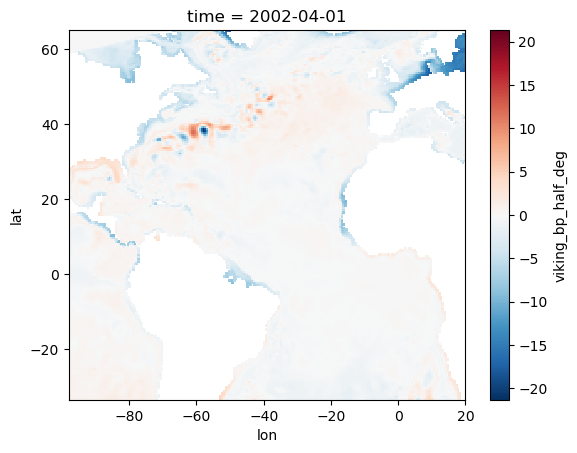

In [83]:
viking_bp_half_deg.isel(time=0).plot()

In [84]:
Raw_cor = xr.corr(grace_common, viking_bp_half_deg, dim="time").compute()
VIKING_bp_std = viking_bp_half_deg.std(dim = "time").compute()
GRACE_bp_std = grace_common.std(dim = "time").compute()

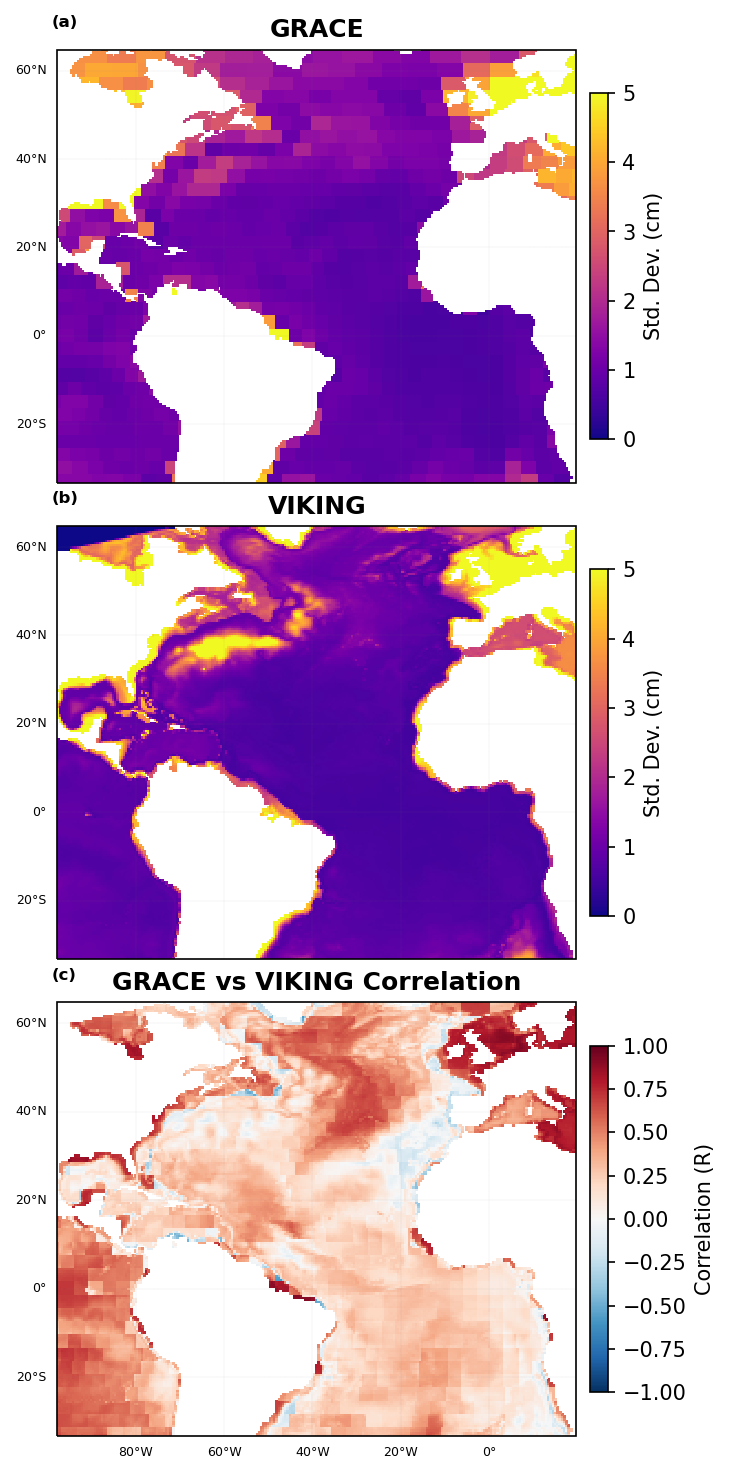

In [85]:
#%%time
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

# Define the datasets and titles
data_list = [GRACE_bp_std, VIKING_bp_std, Raw_cor]
coord_list = [GRACE_bp_std, VIKING_bp_std, Raw_cor]
title_list = [
    "GRACE",
    "VIKING",
    "GRACE vs VIKING Correlation"
]
labels = ['(a)', '(b)', '(c)']

# Create the figure and axes (3 rows, 1 column)
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(6, 12), dpi=150,
                         subplot_kw={'projection': ccrs.PlateCarree(central_longitude=0)},
                         gridspec_kw={'hspace': 0.1})  # Reduce from default ~0.2

# Loop through each subplot
for i, (ax, data, coord, title) in enumerate(zip(axes, data_list, coord_list, title_list)):
    
    # Choose color scale
    if i < 2:
        cmap = 'plasma'
        vmin, vmax = 0, 5  # assuming std dev range
    else:
        cmap = 'RdBu_r'
        vmin, vmax = -1, 1  # correlation range

    # Plot data
    pc = ax.pcolormesh(coord.lon, coord.lat, data,
                       transform=ccrs.PlateCarree(),
                       cmap=cmap, vmin=vmin, vmax=vmax)

    # Map formatting
    #ax.set_global()
    gl = ax.gridlines(draw_labels=True, linestyle='dashed', linewidth=0.05, color='gray')
    gl.right_labels = False
    gl.top_labels = False
    gl.bottom_labels = (i == 2)
    gl.xlabel_style = {'fontsize': 6}
    gl.ylabel_style = {'fontsize': 6}

    #ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '110m',
    #                                            linewidth=0.5, edgecolor='black',
    #                                            facecolor='darkgray'))

    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.text(-0.01, 1.08, labels[i], transform=ax.transAxes,
            fontsize=8, fontweight='bold', va='top', ha='left',
            bbox=dict(facecolor='white', edgecolor='none', pad=1.5, alpha=0.6))

    # Add vertical colorbar to the right of each panel
    cbar = fig.colorbar(pc, ax=ax, orientation='vertical', pad=0.02, shrink=0.8)
    if i < 2:
        cbar.set_label("Std. Dev. (cm)", fontsize=10)
    else:
        cbar.set_label("Correlation (R)", fontsize=10)

# Layout adjustment
#plt.tight_layout()
#plt.savefig("GRACE_VIKING_Correlation_Std.png", dpi=300, bbox_inches='tight')
plt.show()


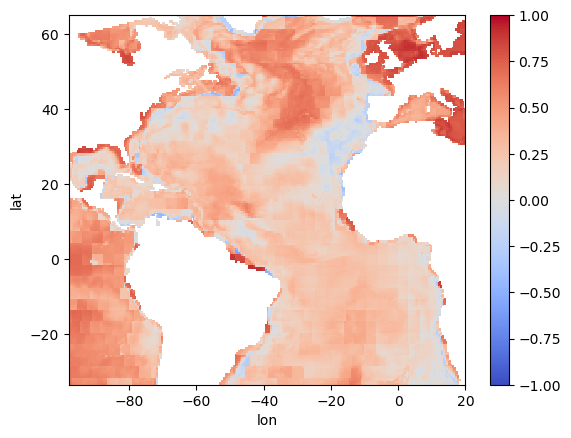

In [86]:
Raw_cor.plot(vmin = -1, vmax =1, cmap = "coolwarm")

In [46]:
# %%time
import numpy as np
import xarray as xr
from scipy.ndimage import label

# --- 1) Build connected-region labels from the reference GRACE field ---
# Round to 2 decimals exactly as before
pb_ref = grace_common.sel(time="2022-06-01").round(decimals=6)

# Work on a plain NumPy array
pb_arr = pb_ref.values
valid = np.isfinite(pb_arr)

# Optional: compress float classes to small ints for faster looping in labeling
# (exact equivalence preserved)
vals = pb_arr[valid]
uniq_vals, inv_codes = np.unique(vals, return_inverse=True)

# 4-connectivity
structure = np.array([[0,1,0],
                      [1,1,1],
                      [0,1,0]], dtype=int)

# Label equal-value connected components, value by value
regions = np.zeros_like(pb_arr, dtype=np.int32)
offset = 0
for k, v in enumerate(uniq_vals):
    mask_k = np.zeros_like(pb_arr, dtype=bool)
    mask_k[valid] = (inv_codes == k)
    if not mask_k.any():
        continue
    lab_k, n_k = label(mask_k, structure=structure)
    if n_k:
        lab_k[lab_k > 0] += offset
        regions += lab_k
        offset += n_k

# regions is 2D int labels with 0 for background/NaN
n_regions = int(regions.max())

# Wrap regions as a coordinate-aligned DataArray for apply_ufunc
regions_da = xr.DataArray(
    regions,
    dims=("lat", "lon"),
    coords={"lat": pb_ref["lat"], "lon": pb_ref["lon"]},
    name="region_id",
)

# --- 2) Vectorized per-time region means using bincount ---
def region_mean_fill(frame_2d, regions_int2d):
    """
    Given a 2D field (lat,lon) and a 2D region label map (same shape, int),
    compute the mean in each region and return a 2D field where each pixel
    is replaced by the mean of its region. NaNs are ignored.
    """
    r = regions_int2d
    x = frame_2d

    m = np.isfinite(x) & (r > 0)
    if not np.any(m):
        return np.full_like(x, np.nan, dtype=np.float64)

    rid = r[m].astype(np.int64, copy=False)
    val = x[m].astype(np.float64, copy=False)

    # sums and counts per region id
    sums  = np.bincount(rid, weights=val, minlength=r.max() + 1)
    counts = np.bincount(rid, minlength=r.max() + 1)

    means = np.full(r.max() + 1, np.nan, dtype=np.float64)
    nz = counts > 0
    means[nz] = sums[nz] / counts[nz]

    # map back to field
    out = means[r]
    return out

# Apply across time with Dask parallelization
region_mean_da = xr.apply_ufunc(
    region_mean_fill,
    viking_bp_half_deg,        # (time, lat, lon)
    regions_da,                # (lat, lon)
    input_core_dims=[["lat", "lon"], ["lat", "lon"]],
    output_core_dims=[["lat", "lon"]],
    vectorize=True,            # loop over 'time' without Python loops
    dask="parallelized",       # dispatch per-time to workers
    output_dtypes=[np.float64]
)

# Name & coords to match your original intent
region_mean_da = region_mean_da.assign_coords(
    time=viking_bp_half_deg["time"],
    lat=grace_common["lat"],
    lon=grace_common["lon"],
).rename("pbo_cm_region_mean")


ValueError: cannot align objects with join='exact' where index/labels/sizes are not equal along these coordinates (dimensions): 'lon' ('lon',)

In [88]:
grace_common


<xarray.DataArray (time: 261, lat: 197, lon: 236)>
array([[[2.22768213, 2.22768213, 1.92150615, ...,        nan,
                nan,        nan],
        [2.22768213, 2.22768213, 1.92150615, ...,        nan,
                nan,        nan],
        [2.22768213, 2.22768213, 1.92150615, ...,        nan,
                nan,        nan],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
...
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[1.82686483, 1.82686483, 1.50669841, ...,        nan,
                nan,        nan],
        [1.82686483, 1.82686483, 1.50669841, ...,        nan,
                nan,        nan],
        [1.82686483, 1.82686483, 1.50669841, ...,        nan,
                nan,        nan],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]]])
Coordinates:
  * lon      (lon) float64 -97.75 -97.25 -96.75 -96.25 ... 18.75 19.25 19.75
  * lat      (lat) float64 -33.25 -32.75 -32.25 -31.75 ... 63.75 64.25 64.75
  * time     (time) datetime64[ns] 2002-04-01 2002-05-01 ... 2023-12-01
Attributes:
    units:      cm
    detrended:  per-pixel polynomial (deg=1) along time

In [113]:
grace_common = grace_common.chunk({'time': -1, 'lat': -1, 'lon': -1})

In [111]:
temp = grace_common.std(dim = 'time')

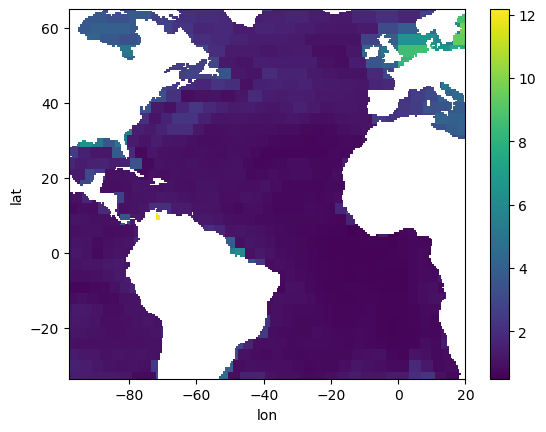

In [112]:
temp.plot()

In [114]:
Raw_cor = xr.corr(region_mean_da, grace_common, dim="time")
VIKING_bp_std = region_mean_da.std(dim = "time")
GRACE_bp_std = grace_common.std(dim = "time")

In [115]:
with ProgressBar():
    VIKING_std = VIKING_bp_std.persist()

In [116]:
temp = VIKING_std

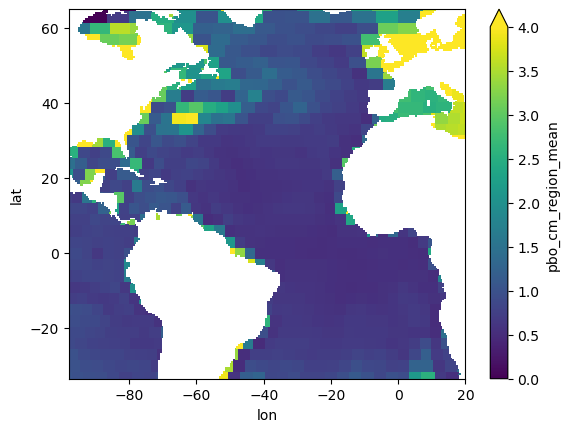

In [117]:
temp.plot(vmin = 0, vmax =4)

In [118]:
std_dif = temp - GRACE_bp_std

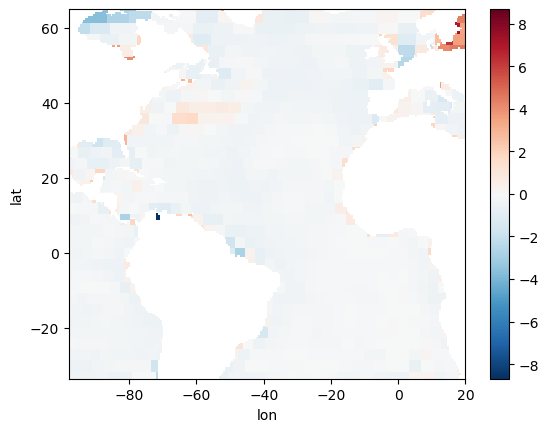

In [119]:
std_dif.plot()

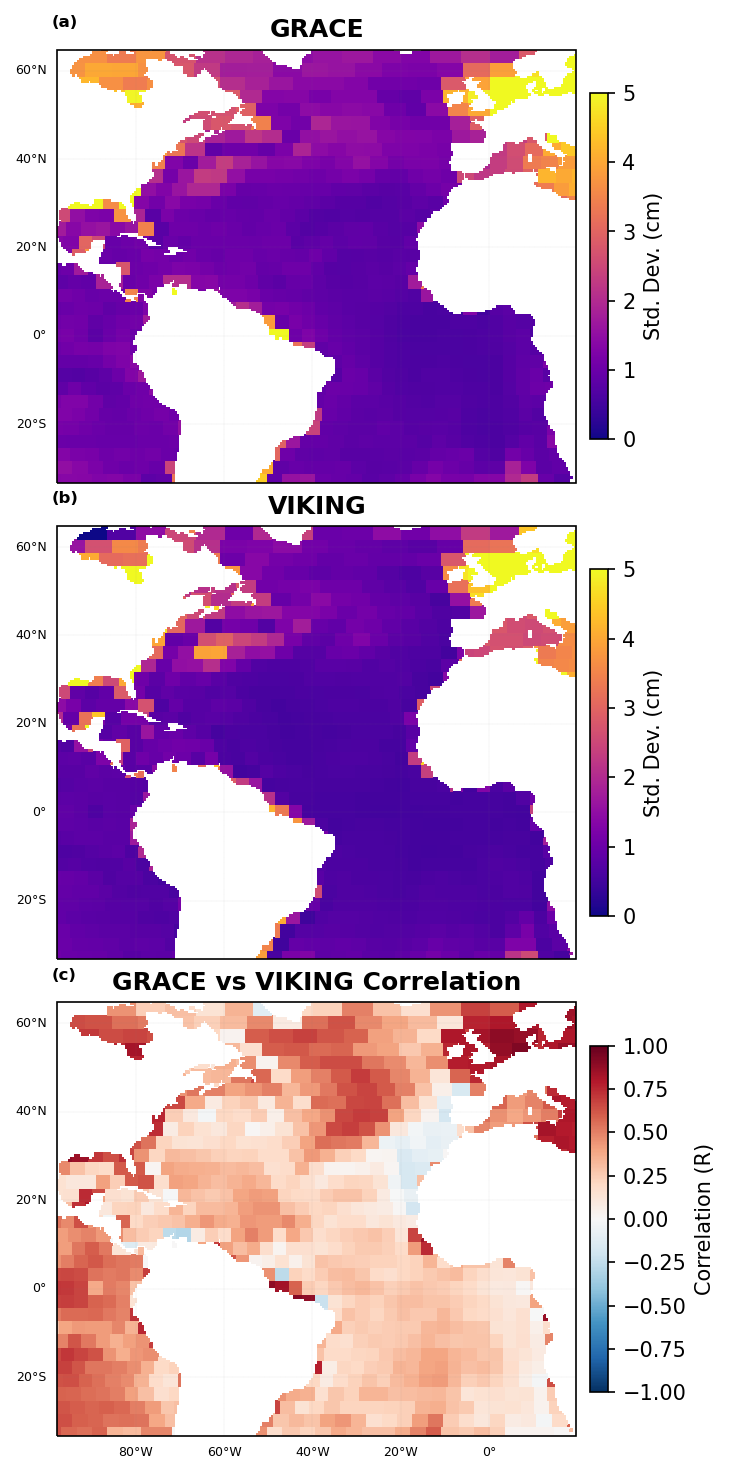

In [120]:
#%%time
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

# Define the datasets and titles
data_list = [GRACE_bp_std, temp, Raw_cor]
coord_list = [GRACE_bp_std, temp, Raw_cor]
title_list = [
    "GRACE",
    "VIKING",
    "GRACE vs VIKING Correlation"
]
labels = ['(a)', '(b)', '(c)']

# Create the figure and axes (3 rows, 1 column)
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(6, 12), dpi=150,
                         subplot_kw={'projection': ccrs.PlateCarree(central_longitude=0)},
                         gridspec_kw={'hspace': 0.1})  # Reduce from default ~0.2

# Loop through each subplot
for i, (ax, data, coord, title) in enumerate(zip(axes, data_list, coord_list, title_list)):
    
    # Choose color scale
    if i < 2:
        cmap = 'plasma'
        vmin, vmax = 0, 5  # assuming std dev range
    else:
        cmap = 'RdBu_r'
        vmin, vmax = -1, 1  # correlation range

    # Plot data
    pc = ax.pcolormesh(coord.lon, coord.lat, data,
                       transform=ccrs.PlateCarree(),
                       cmap=cmap, vmin=vmin, vmax=vmax)

    # Map formatting
    #ax.set_global()
    gl = ax.gridlines(draw_labels=True, linestyle='dashed', linewidth=0.05, color='gray')
    gl.right_labels = False
    gl.top_labels = False
    gl.bottom_labels = (i == 2)
    gl.xlabel_style = {'fontsize': 6}
    gl.ylabel_style = {'fontsize': 6}

    #ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '110m',
    #                                            linewidth=0.5, edgecolor='black',
    #                                            facecolor='darkgray'))

    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.text(-0.01, 1.08, labels[i], transform=ax.transAxes,
            fontsize=8, fontweight='bold', va='top', ha='left',
            bbox=dict(facecolor='white', edgecolor='none', pad=1.5, alpha=0.6))

    # Add vertical colorbar to the right of each panel
    cbar = fig.colorbar(pc, ax=ax, orientation='vertical', pad=0.02, shrink=0.8)
    if i < 2:
        cbar.set_label("Std. Dev. (cm)", fontsize=10)
    else:
        cbar.set_label("Correlation (R)", fontsize=10)

# Layout adjustment
#plt.tight_layout()
#plt.savefig("GRACE_VIKING_Correlation_Std.png", dpi=300, bbox_inches='tight')
plt.show()


In [99]:
import numpy as np
import xarray as xr
from scipy.stats import t

# sample size at each grid cell
n = grace_common.sizes["time"]   # here = 261

df = n - 2

r = Raw_cor  # shorthand

# compute t-statistic
t_stat = r * np.sqrt(df / (1 - r**2))

# two-sided p-value
pval = xr.apply_ufunc(
    lambda x: 2 * (1 - t.cdf(np.abs(x), df)),
    t_stat,
    dask='parallelized',
    output_dtypes=[float]
)
alpha = 0.05
insig = pval >= alpha   # boolean mask of NOT significant

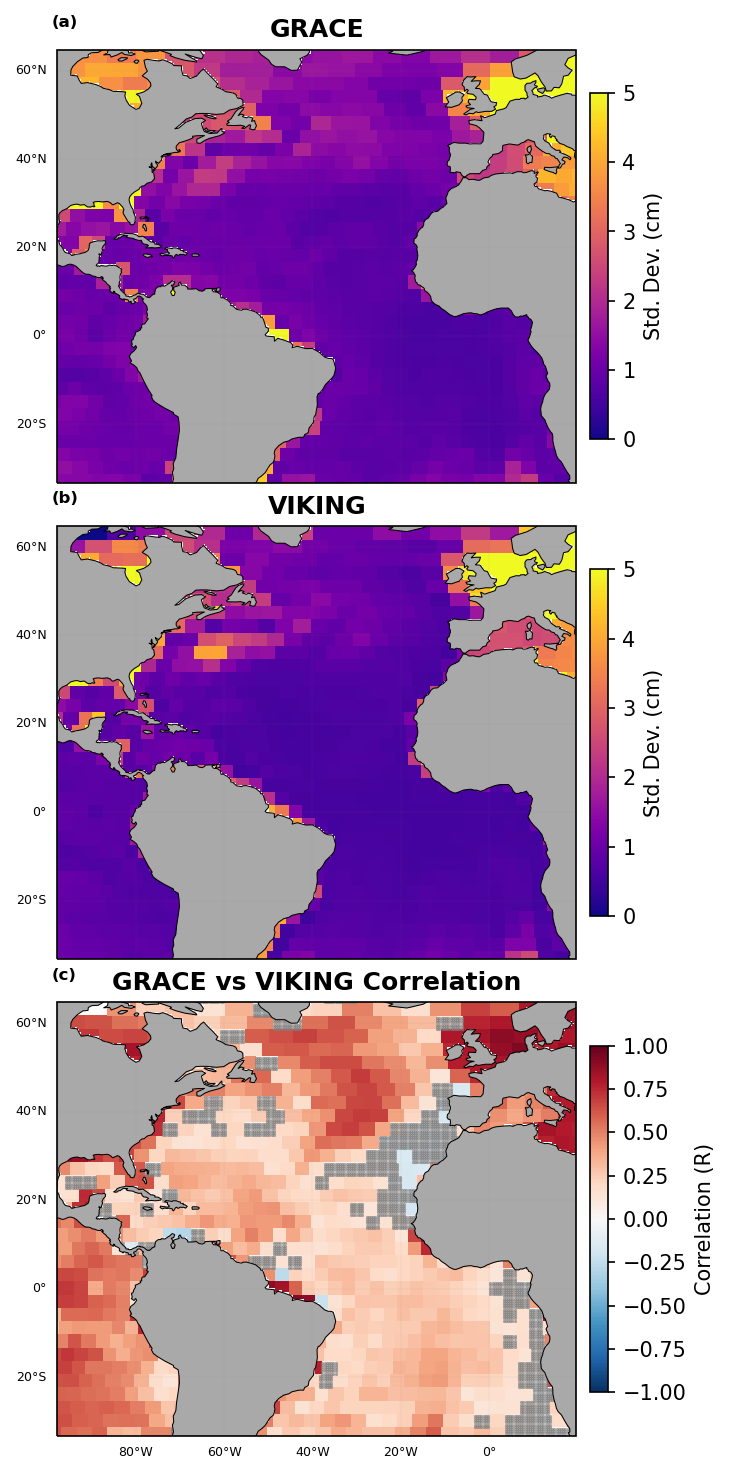

In [100]:
#%%time
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

# Define the datasets and titles
data_list = [GRACE_bp_std, temp, Raw_cor]
coord_list = [GRACE_bp_std, temp, Raw_cor]
title_list = [
    "GRACE",
    "VIKING",
    "GRACE vs VIKING Correlation"
]
labels = ['(a)', '(b)', '(c)']

# Create the figure and axes (3 rows, 1 column)
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(6, 12), dpi=150,
                         subplot_kw={'projection': ccrs.PlateCarree(central_longitude=0)},
                         gridspec_kw={'hspace': 0.1})  # Reduce from default ~0.2

# Loop through each subplot
for i, (ax, data, coord, title) in enumerate(zip(axes, data_list, coord_list, title_list)):
    
    # Choose color scale
    if i < 2:
        cmap = 'plasma'
        vmin, vmax = 0, 5  # assuming std dev range
    else:
        cmap = 'RdBu_r'
        vmin, vmax = -1, 1  # correlation range

    # Plot data
    pc = ax.pcolormesh(coord.lon, coord.lat, data,
                       transform=ccrs.PlateCarree(),
                       cmap=cmap, vmin=vmin, vmax=vmax)

    if i == 2:
    # Add stippling for insignificant correlations
        Y, X = np.meshgrid(coord.lat, coord.lon, indexing="ij")
        
        ax.scatter(
            X[insig],
            Y[insig],
            s=1.0,                  # marker size
            color='gray',
            marker='.',
            alpha=0.7,
            transform=ccrs.PlateCarree()
        )


    # Map formatting
    #ax.set_global()
    gl = ax.gridlines(draw_labels=True, linestyle='dashed', linewidth=0.05, color='gray')
    gl.right_labels = False
    gl.top_labels = False
    gl.bottom_labels = (i == 2)
    gl.xlabel_style = {'fontsize': 6}
    gl.ylabel_style = {'fontsize': 6}

    ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '110m',
                                                linewidth=0.5, edgecolor='black',
                                                facecolor='darkgray'))

    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.text(-0.01, 1.08, labels[i], transform=ax.transAxes,
            fontsize=8, fontweight='bold', va='top', ha='left',
            bbox=dict(facecolor='white', edgecolor='none', pad=1.5, alpha=0.6))

    # Add vertical colorbar to the right of each panel
    cbar = fig.colorbar(pc, ax=ax, orientation='vertical', pad=0.02, shrink=0.8)
    if i < 2:
        cbar.set_label("Std. Dev. (cm)", fontsize=10)
    else:
        cbar.set_label("Correlation (R)", fontsize=10)

# Layout adjustment
#plt.tight_layout()
#plt.savefig("GRACE_VIKING_Correlation_Std.png", dpi=300, bbox_inches='tight')
plt.show()


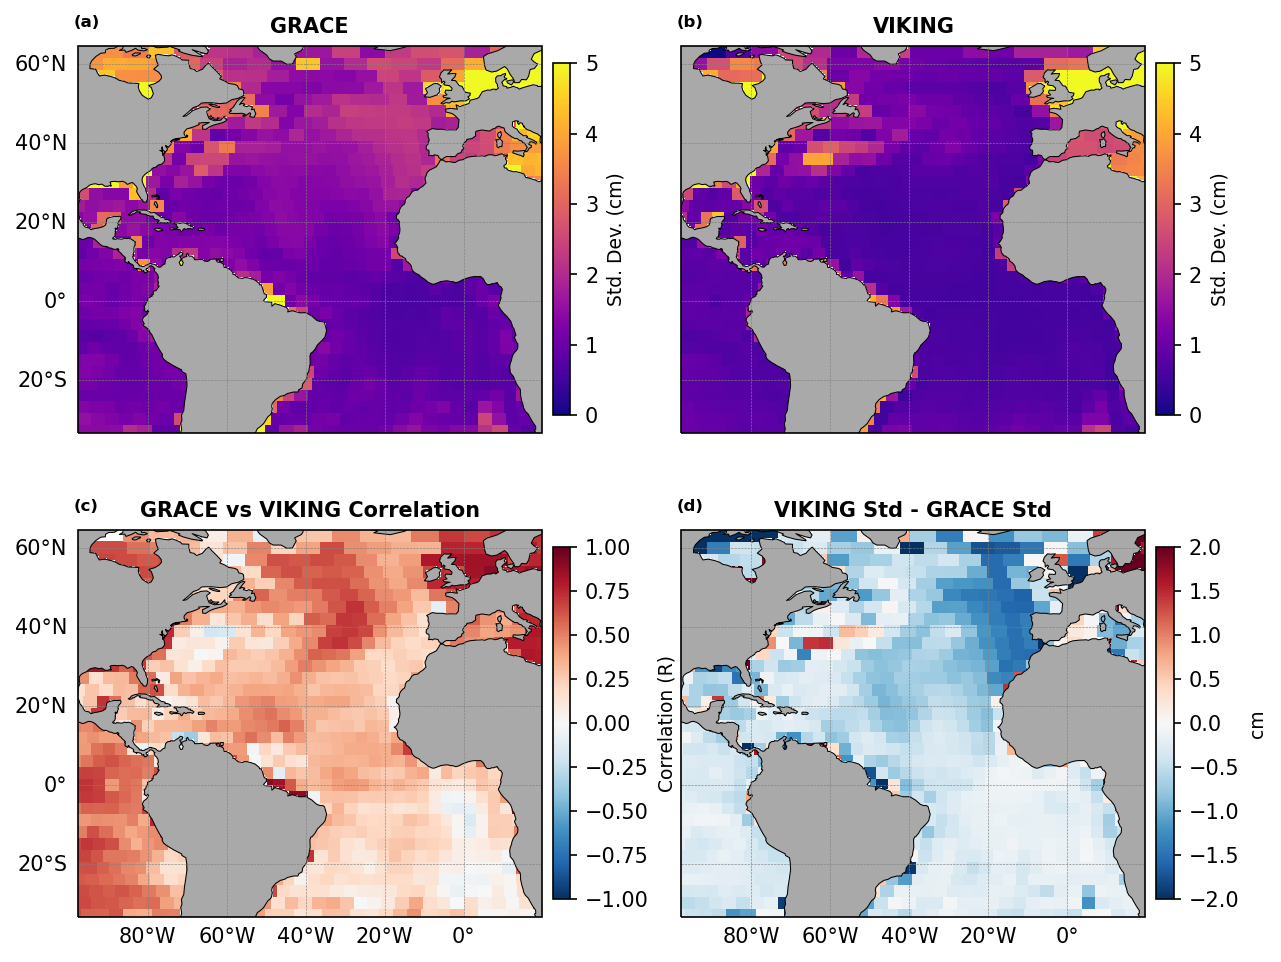

In [70]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

# Data and titles
data_list  = [GRACE_bp_std, temp, Raw_cor, std_dif]
coord_list = [GRACE_bp_std, temp, Raw_cor, std_dif]
title_list = ["GRACE", "VIKING", "GRACE vs VIKING Correlation", "VIKING Std - GRACE Std"]
labels     = ['(a)', '(b)', '(c)', '(d)']

# Figure
fig, axes = plt.subplots(
    nrows=2, ncols=2, figsize=(10, 8), dpi=150,
    subplot_kw={'projection': ccrs.PlateCarree(central_longitude=0)},
    gridspec_kw={'wspace': 0.08, 'hspace': 0.1}
)

# Flatten axes so each `ax` is an Axes, not a row array
for i, (ax, data, coord, title) in enumerate(zip(axes.flat, data_list, coord_list, title_list)):
    # robust coord names
    lon_name = 'lon' if 'lon' in coord.coords else 'longitude'
    lat_name = 'lat' if 'lat' in coord.coords else 'latitude'

    # Choose color scale
    if i < 2:
        cmap, vmin, vmax = 'plasma', 0, 5
    elif i > 2:
        cmap, vmin, vmax = 'RdBu_r', -2, 2    
    else:
        cmap, vmin, vmax = 'RdBu_r', -1, 1

    # Plot
    pc = ax.pcolormesh(
        coord[lon_name], coord[lat_name], data,
        transform=ccrs.PlateCarree(), cmap=cmap, vmin=vmin, vmax=vmax
    )

    # Map cosmetics
    gl = ax.gridlines(draw_labels=True, linestyle='dashed', linewidth=0.3, color='gray')
    try:
        gl.right_labels = False; gl.top_labels = False
        gl.bottom_labels = (i // 2 == 1)   # only bottom row
        gl.left_labels   = (i % 2 == 0)    # only left col
    except AttributeError:
        # Older/newer Cartopy label API fallback
        gl.xlabels_top = False; gl.ylabels_right = False
        gl.xlabels_bottom = (i // 2 == 1)
        gl.ylabels_left   = (i % 2 == 0)

    ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '110m',
                                                linewidth=0.5, edgecolor='black',
                                                facecolor='darkgray'))
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.text(-0.01, 1.08, labels[i], transform=ax.transAxes, fontsize=8, fontweight='bold',
            va='top', ha='left', bbox=dict(facecolor='white', edgecolor='none', pad=1.5, alpha=0.6))

    # Per-panel colorbar
    cbar = fig.colorbar(pc, ax=ax, orientation='vertical', pad=0.02, shrink=0.8)
    labels2 = ["Std. Dev. (cm)", "Std. Dev. (cm)", "Correlation (R)", "cm"]
    cbar.set_label(labels2[i], fontsize=9)


plt.tight_layout(rect=[0, 0, 1, 1])
plt.savefig("GRACE_VIKING_Correlation_Std2.png", dpi=300, bbox_inches='tight')

plt.show()


In [39]:
v = viking_bp_half_deg  # (time, lat, lon), dask-backed

# Ensure helpful chunking for the shuffle (one spatial chunk; moderate time)
v = v.chunk({"time": 12, "lat": -1, "lon": -1})
regions_da = regions_da.chunk({"lat": -1, "lon": -1})

v_stk = v.stack(points=("lat","lon"))
lab_stk = regions_da.stack(points=("lat","lon"))

In [57]:
%%time

import xarray as xr
import numpy as np
from scipy.ndimage import label

# 1) Build region labels once (NumPy) from your GRACE reference slice
#    Keep labels reasonably coarse to avoid millions of groups.
pb_ref = grace_common.sel(time="2022-06-01").round(1)  # coarser rounding than 0.01
labels_np, _ = label(np.isfinite(pb_ref))              # or your preferred labeling
# Alternatively: use the rounded field values themselves as labels:
# labels_np = pb_ref.values

regions_da = xr.DataArray(
    labels_np,
    dims=("lat","lon"),
    coords={"lat": grace_common.lat, "lon": grace_common.lon},
    name="region_id"
).astype("int32")

# 2) Stack space, groupby once, and compute per-region means for all times at once
#    This stays lazy with dask and avoids Python loops entirely.
v = viking_bp_half_deg  # (time, lat, lon), dask-backed

# Ensure helpful chunking for the shuffle (one spatial chunk; moderate time)
v = v.chunk({"time": 12, "lat": -1, "lon": -1})
regions_da = regions_da.chunk({"lat": -1, "lon": -1})

v_stk = v.stack(points=("lat","lon"))
lab_stk = regions_da.stack(points=("lat","lon"))

# Compute region means across points for every time in one shot
# Result dims: (time, region_id)
region_means = v_stk.groupby(lab_stk).mean(dim="points")

# 3) Broadcast those region means back to a field (piecewise-constant over each region)
#    Select per-point region mean using the label at that point, then unstack.
filled = region_means.sel({lab_stk.name: lab_stk}).unstack("points")
filled = filled.transpose("time","lat","lon")
filled.name = "pbo_cm_region_mean"


CPU times: user 33.3 s, sys: 841 ms, total: 34.2 s
Wall time: 43.9 s


In [65]:
with ProgressBar():
    filled.persist()

KeyboardInterrupt: 

In [64]:
with ProgressBar():
    Raw_cor = xr.corr(filled, grace_common, dim="time").persist()
    VIKING_bp_std = filled.std(dim = "time").persist()
    GRACE_bp_std = grace_common.std(dim = "time").persist()

KeyboardInterrupt: 

In [61]:
%%time
import numpy as np
import xarray as xr
from scipy.ndimage import label

# 1. Use a reference time slice from pb
pb_slice = grace_common.sel(time="2022-06-01")
pb_rounded = pb_slice.round(decimals=2)
pb_array = pb_rounded.values

# 2. Structure for 4-connectivity
structure = np.array([[0, 1, 0],
                      [1, 1, 1],
                      [0, 1, 0]])

# 3. Initialize label array
regions = np.zeros_like(pb_array, dtype=int)
label_counter = 1  # unique label ID counter

# 4. Label connected regions per unique value
for val in np.unique(pb_array[~np.isnan(pb_array)]):
    mask = np.isclose(pb_array, val)
    labeled, n_labels = label(mask, structure=structure)
    labeled[labeled > 0] += label_counter - 1
    regions += labeled
    label_counter += n_labels

# 5. Prepare time loop
time_values = viking_bp_half_deg['time'].values
region_ids = np.unique(regions)
region_ids = region_ids[region_ids != 0]

region_mean_array = np.full(viking_bp_half_deg.shape, np.nan)

# 6. Compute means per region at each time
for ti, t in enumerate(time_values):
    pbo_array = viking_bp_half_deg.sel(time=t).values

    for rid in region_ids:
        mask = regions == rid
        region_mean_array[ti][mask] = np.nanmean(pbo_array[mask])

# 7. Wrap as xarray.DataArray
region_mean_da = xr.DataArray(
    data=region_mean_array,
    dims=("time", "lat", "lon"),
    coords={
        "time": viking_bp_half_deg['time'].values,
        "lat": grace_common['lat'].values,
        "lon": grace_common['lon'].values
    },
    name="pbo_cm_region_mean"
)



KeyboardInterrupt



In [51]:
viking_bp_half_deg.isel(time=0)

<xarray.DataArray 'OBP_hPa' (lat: 197, lon: 236)>
dask.array<getitem, shape=(197, 236), dtype=float32, chunksize=(1, 1), chunktype=numpy.ndarray>
Coordinates:
    time     datetime64[ns] 2002-04-01
  * lat      (lat) float64 -33.25 -32.75 -32.25 -31.75 ... 63.75 64.25 64.75
  * lon      (lon) float64 -97.75 -97.25 -96.75 -96.25 ... 18.75 19.25 19.75

In [49]:
grace_common

<xarray.DataArray 'pb' (time: 261, lat: 197, lon: 236)>
array([[[2.58213846, 2.58213846, 2.42395597, ...,        nan,
                nan,        nan],
        [2.58213846, 2.58213846, 2.42395597, ...,        nan,
                nan,        nan],
        [2.58213846, 2.58213846, 2.42395597, ...,        nan,
                nan,        nan],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
...
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[1.26168097, 1.26168097, 0.8183059 , ...,        nan,
                nan,        nan],
        [1.26168097, 1.26168097, 0.8183059 , ...,        nan,
                nan,        nan],
        [1.26168097, 1.26168097, 0.8183059 , ...,        nan,
                nan,        nan],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]]])
Coordinates:
  * lon      (lon) float64 -97.75 -97.25 -96.75 -96.25 ... 18.75 19.25 19.75
  * lat      (lat) float64 -33.25 -32.75 -32.25 -31.75 ... 63.75 64.25 64.75
  * time     (time) datetime64[ns] 2002-04-01 2002-05-01 ... 2023-12-01
Attributes:
    units:    cm